Definujeme SFR

In [38]:
# --- 1. Imports & pretty printing ---------------------------------
import sympy as sp
from sympy import symbols, Eq, Piecewise, hyper, integrate, init_printing
from IPython.display import display        # nice LaTeX output

init_printing(use_latex='mathjax')          # ONE call per notebook

# --- 2. Cosmic star-formation rate (Choudhury-style) --------------
τ, α, β, t0 = symbols('tau_MW alpha_MW beta_MW t0', positive=True)

# instantaneous SFR  ψ(t)
t = sp.symbols('t', positive=True)
SFR = 1 / ((t/τ)**α + (t/τ)**β)

# analytic integral Ψ(T) = ∫₀t0 ψ(t) dt  (Choudhury & Ferrara 2006)
a = 1
b = (1 + β)/(α + β)
c = 1 + b
z = -(t0/τ)**(α + β)
CSFR = t0*(t0/τ)**β * hyper([a, b], [c], z) / (1 + β)      # Ψ(T)
display(Eq(sp.Function('CSFR')(t0), CSFR))

# --- 3. Chabrier (2003) IMF ---------------------------------------
m, m_c, σ, α_IMF, A = symbols('m m_c sigma alpha kappa', positive=True)

log_normal = (1/(m*sp.sqrt(2*sp.pi)*σ)) * sp.exp(-(sp.log(m/m_c))**2/(2*σ**2))
κ = sp.solve(Eq(log_normal.subs(m, 1), symbols('κ')), symbols('κ'))[0]   # continuity

power_law = κ * m**(-α_IMF)
ξ_raw = Piecewise((log_normal, m <= 1), (power_law, True))

# global normalisation ∫ₘₘᵢₙᵐₘₐₓ ξ dm = 1  (adjust limits if you like)
m_min, m_max = 0.01, 100
ξ = ξ_raw                                        # final IMF

# --- 4. Lifetime / “decay” law ------------------------------------
δ = symbols('delta', positive=True)                  # exponent
τ_star = 10 * m**(-δ)                                # in the same units as T


# --- 5. The required SCO(m, T) expression --------------------------
SCH = ξ * (CSFR - CSFR.subs(t0, t0 - τ_star))
display(Eq(sp.Function('SCH')(m, t0), SCH))

T = symbols('T', positive=True, real=True)          # current time
mL, mU = symbols('m_L m_U', positive=True)          # limits of integration
SCH_m_int = integrate(SCH, (m, mL, mU))               # integral of SCO(m, T)
SCH_mt_int = integrate(SCH_m_int, (t0, 0, T))           # integral of SFR(t)


# --- 6. Ready-to-use numerical callable (example parameters) -------
numeric_vals = {
    m_c: 0.079, σ: 0.69, α_IMF: 2.3,                 # Chabrier-single
    τ: 5.0, α: 2.0, β: 1.4,                          # MW SFR history
    δ: 3.5                                           # lifetime exponent
}







                              ⎛    β_MW + 1    │                   ⎞
                    β_MW      ⎜1, ───────────  │        α_MW + β_MW⎟
              ⎛ t₀ ⎞      ┌─  ⎜   α_MW + β_MW  │  ⎛ t₀ ⎞           ⎟
           t₀⋅⎜────⎟    ⋅ ├─  ⎜                │ -⎜────⎟           ⎟
              ⎝τ_MW⎠     2╵ 1 ⎜     β_MW + 1   │  ⎝τ_MW⎠           ⎟
                              ⎜1 + ─────────── │                   ⎟
                              ⎝    α_MW + β_MW │                   ⎠
CSFR(t₀) = ─────────────────────────────────────────────────────────
                                   β_MW + 1                         

                                                                               ↪
                                                                               ↪
             ⎛                   ⎛    β_MW + 1    │                   ⎞        ↪
             ⎜         β_MW      ⎜1, ───────────  │        α_MW + β_MW⎟   ⎛    ↪
             ⎜   ⎛ t₀ ⎞      ┌─  ⎜   α_MW + β_MW  │  ⎛ t₀ ⎞           ⎟   ⎜t₀  ↪
             ⎜t₀⋅⎜────⎟    ⋅ ├─  ⎜                │ -⎜────⎟           ⎟   ⎜─── ↪
             ⎜   ⎝τ_MW⎠     2╵ 1 ⎜     β_MW + 1   │  ⎝τ_MW⎠           ⎟   ⎝    ↪
             ⎜                   ⎜1 + ─────────── │                   ⎟        ↪
             ⎜                   ⎝    α_MW + β_MW │                   ⎠        ↪
SCH(m, t₀) = ⎜───────────────────────────────────────────────────────── - ──── ↪
             ⎝                        β_MW + 1                                 ↪
                                                                               ↪
                            

KeyboardInterrupt: 

Definujeme IMF

In [ ]:
# ------------------------------------------------------------
# Symbols
m      = sp.symbols('m', positive=True)        # stellar mass  [M_sun]
m_c    = sp.symbols('m_c', positive=True)      # log-normal peak mass
sigma  = sp.symbols('sigma', positive=True)    # log-normal width
alpha  = sp.symbols('alpha', positive=True)    # high-mass slope
k, A   = sp.symbols('k A', positive=True)      # continuity + normalization constants

# ------------------------------------------------------------
# Log-normal branch  (m <= 1)
lognormal = (1/(m*sp.sqrt(2*sp.pi)*sigma)) * sp.exp(-(sp.log(m/m_c))**2/(2*sigma**2))

# Solve continuity at m = 1 M_sun  ⇒  k
k_expr = sp.solve(
    sp.Eq(lognormal.subs(m, 1), k * 1**(-alpha)),
    k
)[0]

# Power-law branch  (m > 1)
powerlaw = k_expr * m**(-alpha)

# Piecewise IMF without global normalization
IMF = sp.Piecewise((lognormal, m <= 1), (powerlaw, True))


Define star death time

Now define function in present

In [52]:
star_types = {
    'O': (16, 100),
    'B': (2.1, 16),
    'A': (1.4, 2.1),
    'F': (1.04, 1.4),
    'G': (0.8, 1.04),
    'K': (0.45, 0.8),
    'M': (0.1, 0.45),
    'BH': (20, 100),      # https://en.wikipedia.org/wiki/Black_hole (5-100)
                          # https://en.wikipedia.org/wiki/Supermassive_black_hole
    'NS': (8, 20),        # https://en.wikipedia.org/wiki/Neutron_star (0.7-2.5)
    'WD': (1, 8),         # 0.17-1.4 (https://en.wikipedia.org/wiki/White_dwarf) peaked at 0.6-0.7
    'BD': (0.01, 0.08)  
}

C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\2649665776.py:27: RuntimeWarning: invalid value encountered in power
  z = - (t0 / tau)**(alpha + beta)
C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\2649665776.py:28: RuntimeWarning: invalid value encountered in power
  return ( t0 * (t0/tau)**beta
C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\2649665776.py:67: RuntimeWarning: divide by zero encountered in log10
  log_SCH = np.where(SCH_grid > 0.0, np.log10(SCH_grid), np.nan)


-1.097682949612695


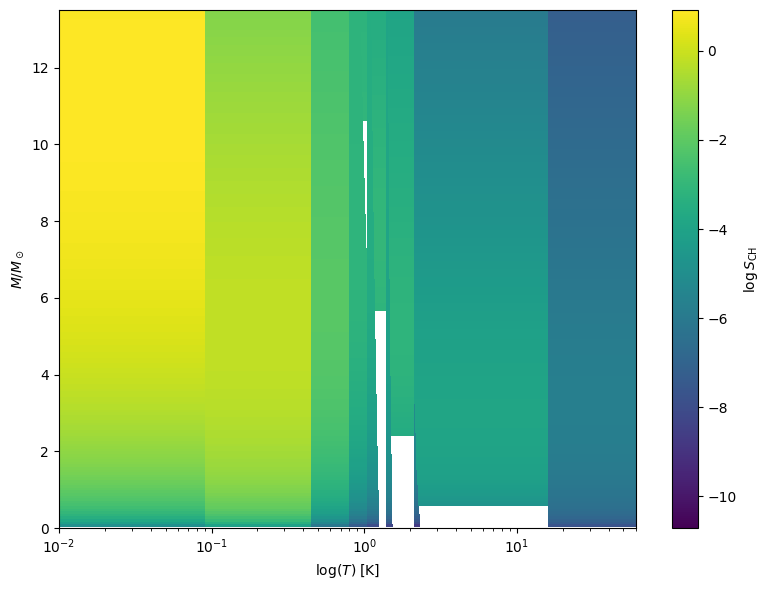

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# -----------------------------
# 1.  Parameters (same as above)
# -----------------------------
tau      = 5.0          # τ  (Gyr)
alpha    = 2.0          # α
beta     = 1.4          # β
delta    = 3.5          # δ
mc       = 0.079        # m_c (M⊙)
sigma    = 0.69         # σ
alpha_IMF = 2.3         # α_IMF

mL, mU = 0.01, 100.0    # M⊙
T_final = 13.5          # Gyr

# -----------------------------
# 2.  Helper functions
# -----------------------------
b_const = (1.0 + beta)/(alpha + beta)
c_const = 1.0 + b_const

def CSFR(t0):
    """Cumulative SFR Ψ(t₀). Works on numpy arrays."""
    z = - (t0 / tau)**(alpha + beta)
    return ( t0 * (t0/tau)**beta
             * special.hyp2f1(1.0, b_const, c_const, z)
             / (1.0 + beta) )

kappa = (1.0/(np.sqrt(2*np.pi)*sigma)) \
        * np.exp(-(np.log(1.0/mc))**2/(2.0*sigma**2))  # continuity factor

def xi(m):
    """Chabrier IMF ξ(m)."""
    log_norm = (1.0/(m*np.sqrt(2*np.pi)*sigma)) \
               * np.exp(-(np.log(m/mc))**2/(2.0*sigma**2))
    powerlaw = kappa * m**(-alpha_IMF)
    return np.where(m <= 1.0, log_norm, powerlaw)

# -----------------------------
# 3.  Build the (m, t₀) grid
# -----------------------------
stars = {}
for key in ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'BD']:
    mL, mU = star_types[key]
    nm, nt = 200, 200
    m_vals = np.logspace(np.log10(mL), np.log10(mU), nm)
    t_vals = np.linspace(0.0, T_final, nt)

    M, T0 = np.meshgrid(m_vals, t_vals)   # shapes (nt, nm)

    # -----------------------------
    # 4.  Compute SCH on the grid
    # -----------------------------
    tau_star = 10.0 * M**(-delta)

    CSFR_atTimet0  = CSFR(t_vals)
    CSFR_prev = np.where(T0 > tau_star, CSFR(t_vals - tau_star), 0.0)
    CSFR_G  = CSFR(13.5)
    CSFR_Gprev = np.where(T0 > tau_star, CSFR(13.5 - tau_star), 0.0)

    SCH_grid = xi(M) * (CSFR_atTimet0 - CSFR_prev)/(CSFR_G - CSFR_Gprev)

    # avoid log of zero
    log_SCH = np.where(SCH_grid > 0.0, np.log10(SCH_grid), np.nan)
    
    stars[key] = {
        'm_vals': m_vals,
        't_vals': t_vals,
        'M': M,
        'T0': T0,
        'SCH_grid': SCH_grid,
        'log_SCH': log_SCH
    }
    # -----------------------------
    # 5.  Plot the heatmap
    # -----------------------------

fig, ax = plt.subplots(figsize=(8, 6))
m_grid = np.array([])
logSCH_list = []
m_list = []
for star in stars.values():
    m_list.append(star['m_vals'])        # (n_m,) per star
    logSCH_list.append(star['log_SCH'])  # (n_m,) per star   ← still 1-D

# concatenate the masses into one long 1-D array
m_grid = np.concatenate(m_list)          # shape (N_total,)

# stack the log_SCH vectors into a 2-D array
#   – rows = different stars, columns = the grid points –
NlogGrid = np.stack(logSCH_list, axis=0)
NlogGrid = np.concatenate(NlogGrid, axis=0)  # shape (n_stars, n_m)

p = 10**NlogGrid
p = np.trapz(p[:,-1], m_grid)  # integrate over m
print(p)
order       = np.argsort(m_grid)
m_grid      = m_grid[order]        # (1600,)
NlogGrid    = NlogGrid[order, :]   # (1600, 200)



# ------------------------------------------------------------------
# 3.  Plot
pcm = ax.pcolormesh(
         m_grid,             # X  (200,)
         t_vals,             # Y  (1600,)
        NlogGrid.T,           # C  (1600, 200)
        shading='auto',     # let Matplotlib pad the edges
      )

ax.set_xlabel(r'$\log(T)\;$[K]')
ax.set_ylabel(r'$M/M_\odot$')
ax.set_aspect('auto')        # let the plot fill the axes
ax.set_xscale('log')
ax.set_ylim(0.0, 13.5)
fig.colorbar(pcm, ax=ax, label=r'$\log S_{\rm CH}$')
fig.tight_layout()


In [99]:
# ---------------------------------------------------------------
# 4.  Linear-scale heat-map with pcolormesh
# ---------------------------------------------------------------
nm, nt = 300, 200                         # grid resolution
m_edges = np.linspace(mL_val, mU_val, nm + 1)      # bin edges in mass
t_edges = np.linspace(0.0, T_val, nt + 1)           # bin edges in time
M_c, T_c = np.meshgrid(                     # cell centres for the integrand
    0.5*(m_edges[:-1] + m_edges[1:]),
    0.5*(t_edges[:-1] + t_edges[1:])
)

# compute SCH on the cell centres
tau_star = 10.0 * M_c**(-delta)
SCH_grid = xi_np(M_c) * (
    CSFR_np(T_c) - np.where(T_c > tau_star, CSFR_np(T_c - tau_star), 0.0)
)

# ---- plot ------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

pcm = ax.pcolormesh(
    m_edges, t_edges, SCH_grid,               # note: edges, not centres
    shading='auto'                            # no gaps
)

ax.set_xlabel(r"stellar mass $m\,[M_\odot]$")
ax.set_ylabel(r"cosmic time $t_0$ [Gyr]")
ax.set_title(r"${\rm SCH}(m,t_0)$   (linear colour scale)")

cbar = fig.colorbar(pcm, ax=ax, label=r"${\rm SCH}$")
plt.tight_layout()
plt.show()


NameError: name 'xi_np' is not defined

In [2]:
star_types = {
    'O': (16, 60),
    'B': (2.1, 16),
    'A': (1.4, 2.1),
    'F': (1.04, 1.4),
    'G': (0.8, 1.04),
    'K': (0.45, 0.8),
    'M': (0.1, 0.45),
    'BH': (20, 100),      # https://en.wikipedia.org/wiki/Black_hole (5-100)
                          # https://en.wikipedia.org/wiki/Supermassive_black_hole
    'NS': (8, 20),        # https://en.wikipedia.org/wiki/Neutron_star (0.7-2.5)
    'WD': (1, 8),         # 0.17-1.4 (https://en.wikipedia.org/wiki/White_dwarf) peaked at 0.6-0.7
    'BD': (0.01, 0.08)  
}

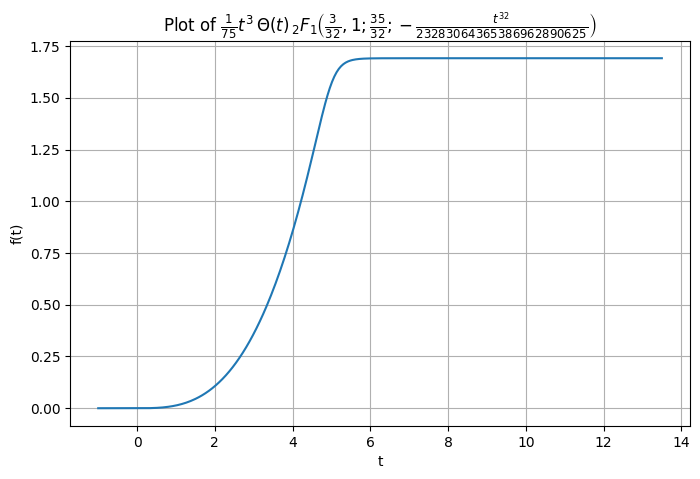

In [343]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1

# Define the function
def f(t):
    t = np.array(t)
    theta = np.heaviside(t, 1)  # HeavisideTheta[t]
    # Apply hyp2f1 elementwise using a list comprehension
    hypergeo = np.array([hyp2f1(3/32, 1, 35/32, -(ti**32) / 23283064365386962890625) for ti in t])
    return (1/75) * t**3 * theta * hypergeo

# Generate t values (must be numbers, not symbols)
t_values = np.linspace(-1, 13.5, 500)
f_values = f(t_values)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t_values, f_values)
plt.title(r'Plot of $\frac{1}{75} t^3 \, \Theta(t) \, _2F_1\left(\frac{3}{32}, 1; \frac{35}{32}; -\frac{t^{32}}{23283064365386962890625}\right)$')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import scipy.integrate
from scipy.special import betainc
from scipy.special import hyp2f1
import scipy.special

# -----------------------------
# 1.  Parameters (same as above)
# -----------------------------
tau      = 1          # τ  (Gyr)
alpha    = 2.0          # α
beta     = 0.5          # β
delta    = 2.5          # δ
mc       = 0.2       # m_c (M⊙)
sigma    = 0.55         # σ
alpha_IMF = 2.3         # α_IMF
T_final = 13.5          # Gyr

# -----------------------------
# 2.  Helper functions
# -----------------------------


# def CSFR(t0):
#     return np.where(t0 <= 0.0, 0, my_SFR(t0)-my_SFR(0))  # Choudhury & Ferrara 2006

"""
def CSFR(t0):
    a = alpha + beta
    b = (beta + 1) / a
    c = 1 + b
    z = - (t0 / tau) ** a
    return np.where(t0 <= 0.0, 0, t0 * (t0 / tau) ** beta * hyp2f1(a, b, c, z)/(1.0+beta)-t0 * (t0 / tau) ** beta * hyp2f1(a, b, c, z)/(1.0+beta))

test = CSFR(0.0)
"""

def f(t0):
    # exponent for the argument of 2F1
    p = (1 + beta) / (alpha + beta)
    z = - (t0 / tau) ** (alpha + beta)
    return (t0 * (t0 / tau) ** beta * hyp2f1(1, p, 1 + p, z)) / (1 + beta)

def CSFR(t):
    return tau*(1-np.exp(-t/tau))*np.heaviside(t,0)  # Choudhury & Ferrara 2006

def CSFR(t):
    return np.heaviside(t,0)

kappa = (1.0/(np.sqrt(2*np.pi)*sigma)) \
        * np.exp(-(np.log(1.0/mc))**2/(2.0*sigma**2))  # continuity factor

def xi(m):
    """Chabrier IMF ξ(m)."""
    log_norm = (1.0/(m*np.sqrt(2*np.pi)*sigma)) \
               * np.exp(-np.log(m/mc)**2/(2.0*sigma**2))
    powerlaw = kappa * m**(-alpha_IMF)
    return np.where(m <= 1.0, log_norm, powerlaw)

# -----------------------------
# 3.  Build the (m, t₀) grid
# -----------------------------
nm, nt = 200, 200
m_vals = np.logspace(np.log10(mL), np.log10(mU), nm)
t_vals = np.linspace(0.0, T_final, nt)

M, T0 = np.meshgrid(m_vals, t_vals)   # shapes (nt, nm)

# -----------------------------
# 4.  Compute SCH on the grid
# -----------------------------
m_cut = delta*np.log(T_final)-1

def tau_star(m):
    """Lifetime τ* = 10.0 * m**(-δ)"""
    
    return 10*m**(-delta)
#np.where(m < m_cut, 15, )

def SCHunnormed(m, t0):
    CSFR_now = CSFR(t0)
    CSFR_prev = CSFR(t0-tau_star(m))
    return xi(m) * (CSFR_now - CSFR_prev)

def SCHnormed(m, t0, xi_integral=1):
    # tau_star = 10.0 * m**(-delta)
    CSFR_now = CSFR(t0)
    CSFR_prev = CSFR(t0 - tau_star(m))
    return xi(m) * (CSFR_now - CSFR_prev)/xi_integral

def SCHunnormad_remnants(m,t0):
    """SCO for remnants (black holes, neutron stars, white dwarfs)"""
    tau_star = 10.0 * m**(-delta)
    CSFR_prev = CSFR(t0 - tau_star)
    return xi(m) * (CSFR_prev)

xi_integral_remnants = 1
def SCHnormad_remnants(m,t0):
    """SCO for remnants (black holes, neutron stars, white dwarfs)"""
    tau_star = 10.0 * m**(-delta)
    CSFR_prev = CSFR(t0 - tau_star)
    return xi(m) * (CSFR_prev)/xi_integral_remnants

T0 = 13.5
  # integrate over
stars = {}
order = ['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O']
for key in order:
    mL, mU = star_types[key]
    #xi_integral, _ = integrate.quad(SCHunnormed, mL, mU, args=(T0,))
    xi_integral  = scipy.integrate.quad(xi, mL, mU, args=(T0,), epsrel=1.e-9)[0]
    print("xi_integral:", xi_integral)
    mean_value   = scipy.integrate.quad(SCHnormed,   mL, mU, args=(T0, xi_integral))[0]
    mean_mass = scipy.integrate.quad(lambda m: m*xi(m), mL, mU)[0]/xi_integral
    #mean_mass = scipy.integrate.quad(lambda m: m*xi(m), mL, mU)[0]/xi0_integral
    nm, nt = 200, 200
    m_vals = np.linspace(mL, mU, nm)
    t_vals = np.linspace(0.0, T_final, nt)
    m_centers = 0.5*(m_vals[:-1] + m_vals[1:])  # cell centres for the integrand
    t_centers = 0.5*(t_vals[:-1] + t_vals[1:])  # cell centres for the integrand
    M, T = np.meshgrid(m_centers, t_centers)   # shapes (nt, nm)
    SCH_grid = SCHnormed(M, T,xi_integral)
    mean_mass = np.sum(m_vals*SCH_grid,axis=1)*(m_vals[1]-m_vals[0])/(m_vals[-1]-m_vals[0])
    
    print(np.sum(SCH_grid[:,-1])/(m_vals[-1]-m_vals[0]))  # check the integral
    mean_N = scipy.integrate.dblquad(SCHnormed, mL, mU, 0.0, T_final, epsrel=1.e-9, args=(xi_integral, ))[0]
    stars[key] = {'m': m_vals, 't': t_vals, 'SCH': SCH_grid}
    print("mean_N:", mean_N)

m_edges = np.concatenate([stars[k]['m'][:-1] for k in order])
m_ticks_centres = [10**(0.5*np.log10(stars[k]['m'][-1]) + 0.5*np.log10(stars[k]['m'][0])) for k in order]
SCH = np.column_stack([stars[k]['SCH'] for k in order])             # shape (nt-1, 8*(nm-1)))))

fig, ax = plt.subplots(figsize=(7, 5))

# x-axis in log(m); use imshow with extent in log10 space
extent = [min(m_edges), max(m_edges), 0.0, T_final]

import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter

#vmin, vmax = SCH.min(), SCH.max() , norm=LogNorm(vmin=vmin, vmax=vmax),
pcm = ax.pcolormesh(np.append(m_edges,mU), t_vals, np.where(SCH < 1e-5, 0, np.log(SCH)), shading='auto')

m_tick_centres = [
    10**(0.5 * (np.log10(stars[k]['m'][0]) + np.log10(stars[k]['m'][-1])))
    for k in order]
axt = ax.twiny()
axt.set_xscale('log')
axt.set_xticks(m_tick_centres)
axt.set_xticklabels(order)
axt.set_xlabel('spectral type')
axt.set_xlim(ax.get_xlim())

# nice log ticks for mass
log_ticks = np.log10([0.01, 0.1, 1, 10, 100])
ax.set_xticks(log_ticks)
ax.set_xticklabels([0.01, 0.1, 1, 10, 100])
ax.set_xscale('log')

ax.set_xlabel(r"stellar mass $m \;[M_\odot]$")
ax.set_ylabel(r"cosmic time $t_0$ [Gyr]")
ax.set_title(r"$\log_{10}\,{\rm SCH}(m,\,t_0)$")
axt.minorticks_off()
cax = inset_axes(ax, width="3%", height="100%", loc='lower left',
                 bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax.transAxes,
                 borderpad=0)  

cb = fig.colorbar(pcm, cax=cax, label=r"$\log_{10}\,\mathrm{SCH}$")
from matplotlib.ticker import LogLocator
cb.ax.set_yscale("log")
cb.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
cb.ax.yaxis.set_major_formatter(LogFormatter(base=10.0))
cb.update_ticks()

plt.tight_layout()
plt.show()


NameError: name 'mL' is not defined

C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\291702954.py:42: RuntimeWarning: invalid value encountered in scalar power
  z = - (t0 / tau) ** a
C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\291702954.py:43: RuntimeWarning: invalid value encountered in scalar power
  result = np.where(t0 <= 0.0, 0, t0 * (t0 / tau) ** beta * hyp2f1(a, b, c, z) / (1.0 + beta))
C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\291702954.py:42: RuntimeWarning: invalid value encountered in power
  z = - (t0 / tau) ** a
C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\291702954.py:43: RuntimeWarning: invalid value encountered in sqrt
  result = np.where(t0 <= 0.0, 0, t0 * (t0 / tau) ** beta * hyp2f1(a, b, c, z) / (1.0 + beta))


BD: mean_value = 1.00000e+00
This 0.0004417873824324236
M: mean_value = 1.00000e+00
This 0.0017841532094953836
K: mean_value = 1.00000e+00
This 0.07965721672560726
G: mean_value = 1.00004e+00
This 1.4415528604288463
F: mean_value = 1.00000e+00
This 13.286893048566945
A: mean_value = 1.00000e+00
This 524.6442541286654
B: mean_value = 9.88054e-01


C:\Users\adamc\AppData\Local\Temp\ipykernel_14028\291702954.py:94: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  mean_value = scipy.integrate.quad(SCHnormed, mL, mU, args=(T0, xi_integral))[0]


This 1.2560151195686626e+16
O: mean_value = 1.11128e+00


c:\Users\adamc\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


This nan


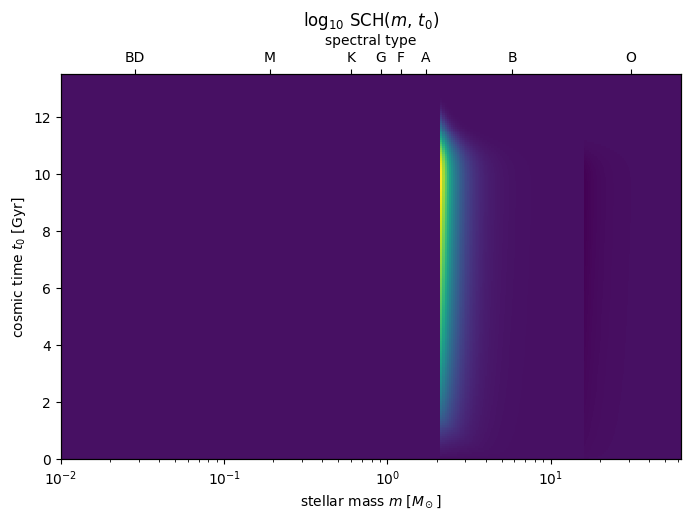

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import scipy.integrate
from scipy.special import betainc
from scipy.special import hyp2f1

# -----------------------------
# 1.  Parameters
# -----------------------------
tau = 12.0          # τ  (Gyr)
alpha = 30          # α
beta = 0.5          # β
delta = 2.5         # δ
mc = 0.2            # m_c (M⊙)
sigma = 0.55        # σ
alpha_IMF = 2.3     # α_IMF
T_final = 13.5      # Gyr

# Star types mass limits
star_types = {
    'BD': (0.01, 0.08),
    'M':  (0.08, 0.45),
    'K':  (0.45, 0.8),
    'G':  (0.8, 1.04),
    'F':  (1.04, 1.4),
    'A':  (1.4, 2.1),
    'B':  (2.1, 16),
    'O':  (16, 100)
}

# -----------------------------
# 2.  Helper functions
# -----------------------------

def CSFR(t0):
    """Cumulative SFR Ψ(t₀)."""
    t0 = np.asarray(t0)
    a = alpha + beta
    b = (beta + 1) / a
    c = 1 + b
    z = - (t0 / tau) ** a
    result = np.where(t0 <= 0.0, 0, t0 * (t0 / tau) ** beta * hyp2f1(a, b, c, z) / (1.0 + beta))
    if result.size == 1:
        return float(result)
    return result

A = np.array([1.0, 0.7, 0.5])
t0_arr = 13.5 - np.array([7.0, 2.5, 1.0])
sigma_arr = np.array([1.0, 0.8, 0.5])

def SCFR(t):
    """Simple cumulative SFH using error functions."""
    cdf = A[0] * (1 + scipy.special.erf((t - t0_arr[0]) / (sigma_arr[0] * np.sqrt(2))))
    cdf += A[1] * (1 + scipy.special.erf((t - t0_arr[1]) / (sigma_arr[1] * np.sqrt(2))))
    cdf += A[2] * (1 + scipy.special.erf((t - t0_arr[2]) / (sigma_arr[2] * np.sqrt(2))))
    cdf *= 0.5
    return float(cdf)

kappa = (1.0/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(np.log(1.0/mc))**2/(2.0*sigma**2))  # continuity factor

def xi(m):
    """Chabrier IMF ξ(m)."""
    log_norm = (1.0/(m*np.sqrt(2*np.pi)*sigma)) * np.exp(-np.log(m/mc)**2/(2.0*sigma**2))
    powerlaw = kappa * m**(-alpha_IMF)
    return np.where(m <= 1.0, log_norm, powerlaw)

def tau_star(m):
    """Lifetime τ* = 10.0 * m**(-δ)"""
    return 10 * m**(-delta)

def SCHunnormed(m, t0):
    CSFR_now = CSFR(t0)
    CSFR_prev = CSFR(t0 - tau_star(m))
    value = 1e-6 * xi(m) * (CSFR_now - CSFR_prev)
    return float(value)

def SCHnormed(m, t0, xi_integral=1):
    CSFR_now = CSFR(t0)
    CSFR_prev = CSFR(t0 - tau_star(m))
    value = 1e-6 * xi(m) * (CSFR_now - CSFR_prev) / xi_integral
    return float(value)

# -----------------------------
# 3.  Grid setup and calculations
# -----------------------------
T0 = 13.5
stars = {}
order = ['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O']

for key in order:
    mL, mU = star_types[key]
    xi_integral = scipy.integrate.quad(SCHunnormed, mL, mU, args=(T0,), epsrel=1e-9)[0]
    mean_value = scipy.integrate.quad(SCHnormed, mL, mU, args=(T0, xi_integral))[0]
    print(f"{key}: mean_value = {mean_value:.5e}")
    
    nm, nt = 200, 200
    m_vals = np.linspace(mL, mU, nm)
    t_vals = np.linspace(0.0, T_final, nt)
    m_centers = 0.5 * (m_vals[:-1] + m_vals[1:])
    t_centers = 0.5 * (t_vals[:-1] + t_vals[1:])
    M, T = np.meshgrid(m_centers, t_centers)
    SCH_grid = SCHnormed(M, T, xi_integral=xi_integral)
    
    stars[key] = {'m': m_vals, 't': t_vals, 'SCH': SCH_grid}

# -----------------------------
# 4.  Plotting
# -----------------------------

m_edges = np.concatenate([stars[k]['m'][:-1] for k in order])
m_ticks_centres = [
    10**(0.5*np.log10(stars[k]['m'][0]) + 0.5*np.log10(stars[k]['m'][-1]))
    for k in order
]
SCH = np.column_stack([stars[k]['SCH'] for k in order])

fig, ax = plt.subplots(figsize=(8, 5))
extent = [min(m_edges), max(m_edges), 0.0, T_final]

pcm = ax.pcolormesh(np.append(m_edges, max(m_edges)*1.05), t_vals, SCH, shading='auto')

axt = ax.twiny()
axt.set_xscale('log')
axt.set_xticks(m_ticks_centres)
axt.set_xticklabels(order)
axt.set_xlabel('spectral type')
axt.set_xlim(ax.get_xlim())

log_ticks = np.log10([0.01, 0.1, 1, 10, 100])
ax.set_xticks(log_ticks)
ax.set_xticklabels([0.01, 0.1, 1, 10, 100])
ax.set_xscale('log')

ax.set_xlabel(r"stellar mass $m \;[M_\odot]$")
ax.set_ylabel(r"cosmic time $t_0$ [Gyr]")
ax.set_title(r"$\log_{10}\,{\rm SCH}(m,\,t_0)$")
axt.minorticks_off()

plt.colorbar(pc


In [241]:
order = ['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O']
for key in order:
    xi_integral = 1
    def SCHunnormed(m, t0):
        tau_star = 10.0 * m**(-delta)
        CSFR_now = CSFR(t0)
        CSFR_prev = CSFR(t0-tau_star)
        return xi(m) * (CSFR_now - CSFR_prev)

    def SCHnormed(m, t0):
        tau_star = 10.0 * m**(-delta)
        CSFR_now = CSFR(t0)
        CSFR_prev = CSFR(t0 - tau_star)
        return xi(m) * (CSFR_now - CSFR_prev)/xi_integral
    
    mL, mU = star_types[key]
    xi_integral, _ = integrate.quad(SCHunnormed, mL, mU, args=(13.5,))
    result, err = integrate.dblquad(SCHnormed, mL, mU, 0, 13.5)
    print(f"{key}: {result:.2g} ± {err:.2g}, {xi_integral:.2g}")

c:\Users\adamc\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\integrate\_quadpack_py.py:606: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


BD: 6.7e-07 ± 1.2e-08, 2.2
M: 0.00056 ± 1.3e-08, 1.1
K: 2.2 ± 2.5e-08, 0.0018
G: 3.1e+02 ± 7e-06, 2.3e-05
F: 6.5e+03 ± 0.00016, 3.3e-06
A: 1.2e+05 ± 0.001, 8.6e-07
B: 1.9e+08 ± 0.033, 2e-07
O: 5.3e+12 ± 7.1e+03, 8.2e-11


INFO: Query finished. [astroquery.utils.tap.core]
Best-fit parameters:
  A     = 9900.954
  τ     = 12.312 Gyr
  α     = 25.880
  β     = 4.661


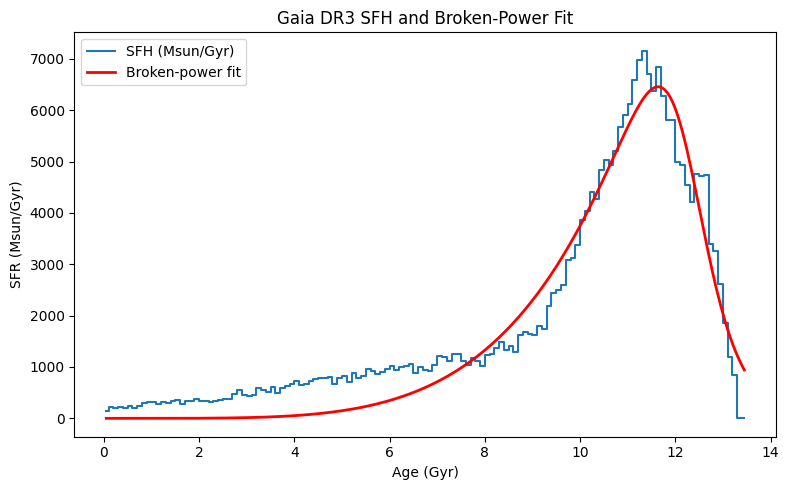

In [83]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1) Fetch high-quality spectroscopic FLAME ages
Gaia.ROW_LIMIT = 100000
adql = """
SELECT TOP 50000
  age_flame_spec AS age
FROM gaiadr3.astrophysical_parameters_supp
WHERE flags_flame_spec = '0'
  AND age_flame_spec IS NOT NULL
"""
job = Gaia.launch_job_async(adql)
table = job.get_results()
df = table.to_pandas()

# 2) Build the SFH histogram
bin_width = 0.1  # Gyr
bins = np.arange(0, df['age'].max() + bin_width, bin_width)
hist_counts, edges = np.histogram(df['age'], bins=bins)
age_centers = edges[:-1] + bin_width / 2
sfr_number = hist_counts / bin_width         # stars per Gyr
mean_mass = 0.5                              # Msun per star
sfr_mass = sfr_number * mean_mass            # Msun per Gyr

sfr_mass = np.flip(sfr_mass)

# 3) Fit the broken-power law: A / [ (t/τ)^α + (t/τ)^(-β) ]
def broken_power(t, A, tau, alpha, beta):
    x = t / tau
    return A / (x**alpha + x**(-beta))

p0 = [sfr_mass.max(), np.median(age_centers), 1.0, 2.0]
bounds = ([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf])
params, cov = curve_fit(broken_power, age_centers, sfr_mass, p0=p0, bounds=bounds)
A_fit, tau_fit, alpha_fit, beta_fit = params

# 4) Output results
print("Best-fit parameters:")
print(f"  A     = {A_fit:.3f}")
print(f"  τ     = {tau_fit:.3f} Gyr")
print(f"  α     = {alpha_fit:.3f}")
print(f"  β     = {beta_fit:.3f}")

# 5) Plot the SFH and the fit
t_fit = np.linspace(age_centers.min(), age_centers.max(), 300)
plt.figure(figsize=(8, 5))
plt.step(age_centers, sfr_mass, where='mid', label='SFH (Msun/Gyr)')
plt.plot(t_fit, broken_power(t_fit, *params), 'r-', lw=2, label='Broken-power fit')
plt.xlabel("Age (Gyr)")
plt.ylabel("SFR (Msun/Gyr)")
plt.title("Gaia DR3 SFH and Broken-Power Fit")
plt.legend()
plt.tight_layout()
plt.show()


Fetched 50000 ages (Gyr)

Best-fit parameters:
  A     = 12101.702
  τ     = 2.350 Gyr
  α     = 2.488
  β     = 1.151


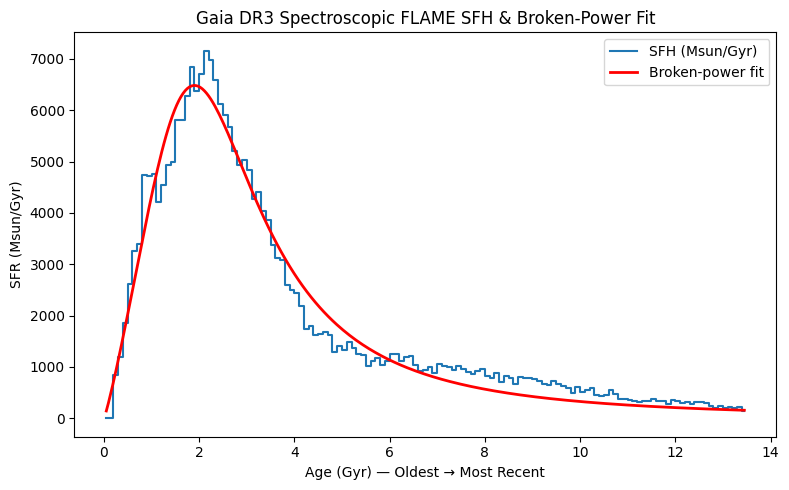

In [82]:
import requests
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from io import StringIO

# 1) TAP Sync endpoint & ADQL (spectroscopic FLAME ages)
TAP_SYNC = "https://gea.esac.esa.int/tap-server/tap/sync"
adql = (
    "SELECT TOP 50000 age_flame_spec AS age "
    "FROM gaiadr3.astrophysical_parameters_supp "
    "WHERE flags_flame_spec = '0' "
    "  AND age_flame_spec IS NOT NULL"
)
params = {
    'REQUEST': 'doQuery',
    'LANG':    'ADQL',
    'FORMAT':  'csv',
    'QUERY':   adql
}

# 2) Download and load into pandas
r = requests.get(TAP_SYNC, params=params)
r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
print(f"Fetched {len(df)} ages (Gyr)")

# 3) Sort by age: oldest → most recent
df = df.sort_values('age').reset_index(drop=True)

# 4) Build the SFH histogram (0.1 Gyr bins)
bin_width = 0.1  # Gyr
bins      = np.arange(0, df['age'].max() + bin_width, bin_width)
counts, edges = np.histogram(df['age'], bins=bins)
age_centers   = edges[:-1] + bin_width/2

# 5) Convert counts → SFR
sfr_number = counts / bin_width            # stars per Gyr
mean_mass  = 0.5                           # Msun per star
sfr_mass   = sfr_number * mean_mass        # Msun per Gyr

sfr_number = np.flip(sfr_number)

# 6) Define & fit the broken‐power law
def broken_power(t, A, tau, alpha, beta):
    x = t / tau
    return A / (x**alpha + x**(-beta))

p0     = [sfr_mass.max(), np.median(age_centers), 1.0, 2.0]
bounds = ([0,0,0,0],[np.inf,np.inf,np.inf,np.inf])
params_fit, cov = curve_fit(broken_power,
                            age_centers, sfr_mass,
                            p0=p0, bounds=bounds)
A_fit, tau_fit, alpha_fit, beta_fit = params_fit

print("\nBest-fit parameters:")
print(f"  A     = {A_fit:.3f}")
print(f"  τ     = {tau_fit:.3f} Gyr")
print(f"  α     = {alpha_fit:.3f}")
print(f"  β     = {beta_fit:.3f}")

# 7) Plot the SFH and the fit
t_fit = np.linspace(age_centers.min(), age_centers.max(), 300)
plt.figure(figsize=(8,5))
plt.step(age_centers, sfr_mass, where='mid', label='SFH (Msun/Gyr)')
plt.plot(   t_fit, broken_power(t_fit, *params_fit),
           'r-', lw=2, label='Broken-power fit')
plt.xlabel("Age (Gyr) — Oldest → Most Recent")
plt.ylabel("SFR (Msun/Gyr)")
plt.title("Gaia DR3 Spectroscopic FLAME SFH & Broken-Power Fit")
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

# 1) Re-fetch up to 50k high-quality spectroscopic FLAME ages
TAP_SYNC = "https://gea.esac.esa.int/tap-server/tap/sync"
adql = (
    "SELECT TOP 50000 age_flame_spec AS age "
    "FROM gaiadr3.astrophysical_parameters_supp "
    "WHERE flags_flame_spec = '0' "
    "  AND age_flame_spec IS NOT NULL"
)
params = {'REQUEST':'doQuery','LANG':'ADQL','FORMAT':'csv','QUERY':adql}
r = requests.get(TAP_SYNC, params=params)
r.raise_for_status()
df = pd.read_csv(StringIO(r.text))

# 2) Histogram the ages (0.1 Gyr bins)
bin_width = 0.1
bins = np.arange(0, df['age'].max() + bin_width, bin_width)
counts, edges = np.histogram(df['age'], bins=bins)
age_centers = edges[:-1] + bin_width/2

# 3) Find peak bin
peak_idx = counts.argmax()
peak_age = age_centers[peak_idx]
peak_count = counts[peak_idx]

# 4) Display result
print(f"Peak age bin center: {peak_age:.2f} Gyr, Count: {peak_count} stars")


Peak age bin center: 2.15 Gyr, Count: 1432 stars


In [52]:
import requests
import pandas as pd
from io import StringIO

# Gaia TAP synchronous endpoint
url = "https://gea.esac.esa.int/tap-server/tap/sync"

# ADQL to fetch the global SFH table
params = {
    'REQUEST': 'doQuery',
    'LANG':    'ADQL',
    'FORMAT':  'csv',
    'QUERY':  (
        "SELECT age_bin_start, age_bin_end, sfr_surface_density "
        "FROM bgm.global_sfh "
        "ORDER BY age_bin_start"
    )
}

# Download the CSV
response = requests.get(url, params=params)
response.raise_for_status()

# Load into a pandas DataFrame
df_global_sfh = pd.read_csv(StringIO(response.text))

# Compute age‐bin centers
df_global_sfh['age_center'] = 0.5 * (
    df_global_sfh['age_bin_start'] + df_global_sfh['age_bin_end']
)

# Inspect
print(df_global_sfh)


HTTPError: 400 Client Error: 400 for url: https://gea.esac.esa.int/tap-server/tap/sync?REQUEST=doQuery&LANG=ADQL&FORMAT=csv&QUERY=SELECT+age_bin_start%2C+age_bin_end%2C+sfr_surface_density+FROM+bgm.global_sfh+ORDER+BY+age_bin_start

In [71]:
from astroquery.vizier import Vizier
import pandas as pd

# 1) Configure Vizier for unlimited rows
Vizier.ROW_LIMIT = -1

# 2) Find the BGM FASt catalogue in VizieR
viz = Vizier(columns=['*'])
catalogs_info = viz.find_catalogs('J/A+A/620/A79')
catalog_ids = list(catalogs_info.keys())

print("Catalog IDs in J/A+A/620/A79:")
print(catalog_ids)

# 3) Download all tables from that catalogue
catalogs = viz.get_catalogs(catalog_ids)
print("\nRetrieved table keys:")
print(list(catalogs.keys()))

# 4) Identify the key for the global SFH ('table2')
table2_key = next(k for k in catalogs.keys() if k.endswith('/table2'))
print(f"\nGlobal SFH is in: {table2_key}")

# 5) Convert Table2 to pandas DataFrame
df_global_sfh = catalogs[table2_key].to_pandas()

# 6) Display full DataFrame without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("\nGlobal SFH (Table 2):")
print(df_global_sfh)

# 7) Compute and add age_bin_center
df_global_sfh


Catalog IDs in J/A+A/620/A79:
['I/16', 'I/85', 'I/138', 'I/195', 'I/196', 'I/207', 'I/244A', 'I/277', 'I/300', 'I/303', 'I/313', 'I/322A', 'I/323', 'I/329', 'I/331', 'I/347', 'I/352', 'I/353', 'I/354', 'I/382', 'II/6', 'II/50', 'II/59B', 'II/95', 'II/97', 'II/108', 'II/143A', 'II/146', 'II/162', 'II/170', 'II/188', 'II/200', 'II/202', 'II/208', 'II/211', 'II/213', 'II/221A', 'II/222', 'II/228A', 'II/239', 'II/240', 'II/243', 'II/246', 'II/255', 'II/261', 'II/266', 'II/281', 'II/284', 'II/286', 'II/287', 'II/288', 'II/290', 'II/292', 'II/296', 'II/297', 'II/312', 'II/313', 'II/314', 'II/319', 'II/321', 'II/328', 'II/332', 'II/333', 'II/337', 'II/340', 'II/341', 'II/344', 'II/346', 'II/347', 'II/350', 'II/351', 'II/356', 'II/357', 'II/358', 'II/360', 'II/361', 'II/364', 'II/365', 'II/366', 'II/370', 'II/371', 'II/373', 'II/374', 'II/378', 'II/379', 'II/380', 'II/381', 'II/382', 'II/383', 'II/384', 'II/386', 'III/7A', 'III/14', 'III/76A', 'III/105', 'III/121', 'III/135A', 'III/147', 'III/


Retrieved table keys:
['I/16/catalog', 'I/85/cpc2', 'I/138/main', 'I/195/catalog', 'I/196/main', 'I/196/annex1', 'I/196/notes', 'I/207/catalog', 'I/244A/bwc', 'I/277/spmcat', 'I/277/spmccd', 'I/277/spmfld', 'I/300/pm2000', 'I/303/cdc2000', 'I/313/lqrf', 'I/322A/out', 'I/323/icrf2', 'I/329/urat1', 'I/347/gaia2dis', 'I/352/gedr3dis', 'I/353/gsc242', 'I/354/starhorse2021', 'I/382/calern', 'I/382/merate', 'I/382/nice-1', 'I/382/nice-2', 'II/6/catalog', 'II/6/filters', 'II/50/ubv', 'II/59B/catalog', 'II/95/data', 'II/95/notes', 'II/97/ans', 'II/108/data', 'II/143A/catalog', 'II/143A/refs', 'II/146/data', 'II/162/data1', 'II/162/data2', 'II/162/data3', 'II/162/data4', 'II/162/data5', 'II/162/data6', 'II/162/data7', 'II/162/data8', 'II/162/data9', 'II/162/table4', 'II/162/table5', 'II/162/table6', 'II/162/table7', 'II/170/ltpv1', 'II/170/stars1', 'II/188/ltpv2', 'II/188/stars2', 'II/200/ltpv3', 'II/200/stars3', 'II/202/ltpv4', 'II/202/stars4', 'II/208/bv', 'II/211/ircam', 'II/211/catalog', '

,Name,Q,U,e_Q,Pol,PA,r,Simbad,_RA,_DE
0,HD 99225,-0.2110,-0.1392,0.0071,0.25,106.699997,360,Simbad,171.29676,5.73946
1,HD 99835,0.0361,0.1240,0.0362,0.13,36.900002,550,Simbad,172.30661,6.09829
2,HD 99905,-0.0449,0.1549,0.0114,0.16,53.099998,215,Simbad,172.39918,3.77993
3,HD 100415,0.0302,0.3084,0.0222,0.31,42.200001,154,Simbad,173.35324,4.13417
4,HD 100416,-0.0443,0.0705,0.0054,0.08,61.099998,280,Simbad,173.33224,3.36250
5,HD 100436,0.0321,0.1447,0.0461,0.15,38.700001,520,Simbad,173.37591,5.86213
6,HD 100776,-0.1187,0.1029,0.0106,0.16,69.599998,325,Simbad,173.98484,6.76820
7,HD 100872,-0.1093,0.1342,0.0142,0.17,64.599998,154,Simbad,174.14234,6.10644
8,HD 100948,0.0366,0.0530,0.0155,0.06,27.700001,230,Simbad,174.28869,4.96299
9,HD 100974,-0.0535,0.1935,0.0183,0.20,52.700001,167,Simbad,174.32436,6.27003


In [72]:
import requests
import pandas as pd
from io import StringIO

# 1) Fetch the raw bins
resp = requests.get(
    "https://gea.esac.esa.int/tap-server/tap/sync",
    params={
        'REQUEST': 'doQuery',
        'LANG':    'ADQL',
        'FORMAT':  'csv',
        'QUERY':   (
            "SELECT age_bin_start, age_bin_end, sfr_surface_density "
            "FROM bgm.global_sfh "
            "ORDER BY age_bin_start"
        )
    }
)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))

# 2) Compute age‐bin centers and widths
df['age_center'] = 0.5 * (df['age_bin_start'] + df['age_bin_end'])
df['bin_width']  =   df['age_bin_end']   - df['age_bin_start']

# 3) Inspect
print(df[['age_bin_start','age_bin_end','age_center','bin_width',
          'sfr_surface_density']].to_string(index=False))


HTTPError: 400 Client Error: 400 for url: https://gea.esac.esa.int/tap-server/tap/sync?REQUEST=doQuery&LANG=ADQL&FORMAT=csv&QUERY=SELECT+age_bin_start%2C+age_bin_end%2C+sfr_surface_density+FROM+bgm.global_sfh+ORDER+BY+age_bin_start

In [75]:
from astroquery.vizier import Vizier

# 1) Allow unlimited rows
Vizier.ROW_LIMIT = -1

# 2) Download the BGM FASt catalogue
viz      = Vizier(columns=['*'])
catalogs = viz.get_catalogs('J/A+A/620/A79')

# 3) See exactly which keys (tables) you got back
print("Available tables in J/A+A/620/A79:")
for key in catalogs.keys():
    print(" -", key)

# 4) Once you see e.g. 'J/A+A/620/A79/table2' or similar, use that exact key:
table2_key = list(catalogs.keys())[1]  # or pick by name after inspecting
print("\nUsing key:", table2_key)

# 5) Convert that table to pandas
df_global_sfh = catalogs[table2_key].to_pandas()

# 6) Compute age-bin centers
df_global_sfh['age_bin_center'] = 0.5*(df_global_sfh['age_bin_start'] + df_global_sfh['age_bin_end'])

# 7) Inspect the SFH
import pandas as pd
pd.set_option('display.max_rows', None)
print(df_global_sfh[['age_bin_start','age_bin_end','age_bin_center','sfr_surface_density']])


Available tables in J/A+A/620/A79:
 - J/MNRAS/430/1125/sources
 - J/MNRAS/430/1125/emlines
 - J/MNRAS/430/1125/tableb3
 - J/ApJ/910/42/table1
 - J/ApJ/910/42/table2
 - J/A+A/572/L5/table1
 - J/AJ/139/2034/stars
 - J/AJ/139/2034/table1
 - J/AJ/139/2034/table2
 - J/AJ/139/2034/table3
 - J/AJ/139/2034/table4
 - J/ApJ/789/104/table1
 - J/ApJ/789/104/refs
 - J/ApJ/789/104/table2
 - J/ApJ/789/104/table5
 - J/ApJ/773/L36/gcdata
 - J/ApJ/773/L36/table2
 - J/ApJ/697/1741/table1
 - J/A+A/468/353/table14
 - J/A+A/617/A77/list
 - J/A+A/560/A73/list
 - J/ApJ/659/1040/table1
 - J/ApJ/659/1040/table5
 - J/ApJ/794/107/sample
 - J/ApJ/794/107/table1
 - J/A+A/625/A68/tableb1
 - J/AJ/101/625/table1
 - J/AJ/101/625/table2
 - J/AJ/101/625/table3
 - J/AJ/101/625/table4
 - J/AJ/101/625/notes
 - J/ApJ/891/129/table2
 - J/ApJ/891/129/table3
 - J/ApJ/709/447/table1
 - J/ApJ/620/961/table1
 - J/ApJ/620/961/table2
 - J/ApJ/620/961/table4
 - J/ApJ/620/961/table5
 - J/ApJ/703/1672/table1
 - J/ApJ/703/1672/table2
 -

KeyError: 'age_bin_start'

In [78]:
import requests

# VizieR TAP endpoint
TAP_VIZIER = "http://tapvizier.u-strasbg.fr/TAPVizieR/tap/sync"

# ADQL to grab only the header (no data) for table2 in J/A+A/620/A79
adql = """
SELECT *
FROM "J/A+A/620/A79/table2"
LIMIT 0
"""

resp = requests.get(TAP_VIZIER, params={
    'REQUEST': 'doQuery',
    'LANG':    'ADQL',
    'FORMAT':  'ascii',   # ASCII will give you a plain-text table with the header row
    'QUERY':   adql.strip()
})
resp.raise_for_status()

# Print the raw text response (you should see the column names in the first line)
print(resp.text.splitlines()[0])


HTTPError: 400 Client Error: 400 for url: http://tapvizier.u-strasbg.fr/TAPVizieR/tap/sync?REQUEST=doQuery&LANG=ADQL&FORMAT=ascii&QUERY=SELECT+%2A%0AFROM+%22J%2FA%2BA%2F620%2FA79%2Ftable2%22%0ALIMIT+0

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load your FLAME ages CSV (must contain 'age' column in Gyr)
df = pd.read_csv("flame_ages.csv")  

# 2) Define binning for SFH
bin_width = 0.1  # Gyr
bins = np.arange(0, df['age'].max() + bin_width, bin_width)

# 3) Histogram ages
hist_counts, edges = np.histogram(df['age'], bins=bins)
age_centers = edges[:-1] + bin_width/2

# 4) Convert to raw SFR (# stars per Gyr)
sfr_number = hist_counts / bin_width  # stars/Gyr

# 5) Convert to mass‐based SFR assuming mean mass (e.g., 0.5 Msun)
mean_mass = 0.5  # Msun
sfr_mass = sfr_number * mean_mass     # Msun/Gyr

# 6) Plot both
fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

ax[0].step(age_centers, sfr_number, where='mid')
ax[0].set_ylabel("Stars per Gyr")
ax[0].set_title("Number‐based SFH")

ax[1].step(age_centers, sfr_mass, where='mid', color='orange')
ax[1].set_xlabel("Age (Gyr)")
ax[1].set_ylabel("Mass ($M_\\odot$) per Gyr")
ax[1].set_title("Mass‐based SFH (assuming 0.5 $M_\\odot$/star)")

plt.tight_layout()
plt.show()

# 7) Save for fitting
sfh_df = pd.DataFrame({
    'age_center': age_centers,
    'sfr_number': sfr_number,
    'sfr_mass': sfh_mass
})
sfh_df.to_csv("sfh_histogram.csv", index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'flame_ages.csv'

In [40]:
import numpy as np
from scipy.optimize import curve_fit

# age_centers and sfr_values from the table above
age_centers = np.array([0.075, 0.575, 1.50, 2.50, 3.50, 4.50, 5.50, 6.50, 7.50, 8.50, 9.50])
sfr_values  = np.array([1.6,   2.5,   2.1,  1.7,  1.8,  1.8,  2.3,  2.3,  3.4,  3.4,  3.4])

def double_gauss(t, tau, alpha, beta, A):
    return A/(((t/tau)**alpha)+((t/tau)**(-beta))) 
# initial guesses: amplitudes ~peak heights, means near peaks, widths ~1 Gyr

p0 = [5, 2.0, 1.4, 1]  # tau, alpha, beta, A
params, cov = curve_fit(double_gauss, age_centers, sfr_values, p0=p0)

tau, alpha, beta, A = params
print(f"tau={tau:.2f}, alpha={alpha:.2f}, beta={beta:.2f}, A={A:.2f}")

tau=1.41, alpha=-0.16, beta=0.16, A=4.22


In [23]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# your data arrays
t   = df['age_center'].values           # in Gyr
sfr = df['sfr_surface_density'].values

# model: A / [ (t/tau)^alpha + (t/tau)^(-beta) ]
def broken_power(t, A, tau, alpha, beta):
    x = t / tau
    return A / ( x**alpha + x**(-beta) )

# initial guesses:
#   A     ~ order of peak SFR (~3)
#   tau   ~ characteristic time (e.g. 5 Gyr)
#   alpha ~ rising slope (e.g. 1)
#   beta  ~ falling slope (e.g. 2)
p0 = [3.0, 5.0, 1.0, 2.0]

# bounds: A>0, tau>0, alpha>0, beta>0
bounds = ([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf])

# perform the fit
params, cov = curve_fit(broken_power, t, sfr, p0=p0, bounds=bounds)

A_fit, tau_fit, alpha_fit, beta_fit = params
print(f"A     = {A_fit:.3f}")
print(f"τ     = {tau_fit:.3f} Gyr")
print(f"α     = {alpha_fit:.3f}")
print(f"β     = {beta_fit:.3f}")

# plot data + best‐fit
t_fit = np.linspace(t.min(), t.max(), 200)
sfr_fit = broken_power(t_fit, *params)

plt.scatter(t, sfr, label="data")
plt.plot(t_fit, sfr_fit, label="broken‐power fit")
plt.xlabel("Age (Gyr)")
plt.ylabel("SFR (pc⁻² Gyr⁻¹)")
plt.legend()
plt.show()


NameError: name 'df' is not defined

In [22]:
# Milky‐Way SFR library – models (2), (3) and (5)
# -------------------------------------------------
# (2) delayed-τ model
# (3) log-normal model
# (5) bursty model = arbitrary base + Gaussian bursts
#
# Všechny funkce přijímají časy *t* (v Gyr) jako numpy pole a vracejí
# SFR ψ(t) (libovolné jednotky).  Kumulativní hmotu C(t)=∫ψ dt dostanete
# přímo analytickými vzorci – nikde se už nepoužívá numerická integrace.

import numpy as np
from scipy.special import erf

__all__ = [
    "sfr_delayed_tau", "cumulative_delayed_tau",
    "sfr_lognormal", "cumulative_lognormal",
    "sfr_bursty", "cumulative_bursty",
    "CSFR"
]

# -------------------------------------------------
# (2)  delayed-τ  :  ψ(t)=ψ₀ (t/τ²) e^{-t/τ}
# -------------------------------------------------

def sfr_delayed_tau(t, psi0=1.0, tau=5.0):
    """Star-formation rate of the delayed-τ model."""
    t = np.asarray(t, dtype=float)
    return psi0 * (t / tau**2) * np.exp(-t / tau) 


def cumulative_delayed_tau(t, psi0=1.0, tau=5.0):
    """Analytic cumulative mass for the delayed-τ model."""
    t = np.asarray(t, dtype=float)
    return tau*(tau-np.exp(-t / tau)*(tau+t))* np.heaviside(t, 0.0)


# -------------------------------------------------
# (3)  log-normal  :  ψ(t)=ψ₀ /(t σ√{2π}) exp[-(ln t−μ)² /(2σ²)]
# -------------------------------------------------

def sfr_lognormal(t, psi0=1.0, mu=np.log(4.0), sigma=0.5):
    """Log-normal star-formation history."""
    t = np.asarray(t, dtype=float)
    psi = np.zeros_like(t)
    mask = t > 0.0
    tt = t[mask]
    psi[mask] = psi0 / (tt * sigma * np.sqrt(2.0 * np.pi)) * \
        np.exp(- (np.log(tt) - mu) ** 2 / (2.0 * sigma ** 2))
    return psi


def cumulative_lognormal(t, psi0=1.0, mu=np.log(4.0), sigma=0.5):
    """Analytic cumulative mass for the log-normal model."""
    t = np.asarray(t, dtype=float)
    cum = np.zeros_like(t)
    mask = t > 0.0
    tt = t[mask]
    z = (np.log(tt) - mu) / (sigma * np.sqrt(2.0))
    cum[mask] = psi0 * 0.5 * (1.0 + erf(z))
    return cum


# -------------------------------------------------
# (5)  Bursty SFR  =  base(t)  +  Σ_k  B_k exp[-(t-t_k)² /(2 σ_k²)]
# -------------------------------------------------

# –– základní SFR pro burst-model (default: delayed-τ) – má i analytickou kumulativu
_default_base_sfr = sfr_delayed_tau
_default_base_cum = cumulative_delayed_tau


def sfr_bursty(t, *,
               base_func=_default_base_sfr, base_kwargs=None,
               bursts=((1.0, 5.7, 0.25), (0.5, 1.9, 0.25), (0.4, 1.0, 0.25))):
    """Bursty SFR – Gaussian pulses plus underlying base SFR."""
    if base_kwargs is None:
        base_kwargs = {}
    t = np.asarray(t, dtype=float)
    sfr = base_func(t, **base_kwargs)
    for B, tk, sig in bursts:
        sfr += B * np.exp(- (t - tk) ** 2 / (2.0 * sig ** 2))
    return sfr


def cumulative_bursty(t, *,
                      base_cum_func=_default_base_cum, base_kwargs=None,
                      bursts=((1.0, 5.7, 0.25), (0.5, 1.9, 0.25), (0.4, 1.0, 0.25))):
    """Analytic cumulative mass for the bursty model."""
    if base_kwargs is None:
        base_kwargs = {}
    t = np.asarray(t, dtype=float)
    cum = base_cum_func(t, **base_kwargs)
    for B, tk, sig in bursts:
        pref = B * sig * np.sqrt(np.pi / 2.0)
        cum += pref * (erf((t - tk) / (sig * np.sqrt(2.0))) + erf(tk / (sig * np.sqrt(2.0))))
    return cum




def _safe_exp(x):
    """e^{-x} se saturací pro x<0 i x≫700"""
    x_clipped = np.clip(x, 0.0, 700.0)       # ničím od 0 do 700
    return np.exp(-x_clipped)

def cdf_infall(t):
    """Analytická CDF přísunu plynu, chráněná proti přetečení."""
    tau1, tau2, tau3 = 0.103, 4.110, 0.150
    t1,  t2          = 4.085, 11.000
    A,   B,   C      = 102.254, 7.647, 73.209
    t_in = t
    t    = np.atleast_1d(t).astype(float)

    # negativní časy → 0 (nic se ještě nepřisypalo)
    t[t < 0] = 0.0

    F = np.zeros_like(t)

    # 0 – t1
    m1 = t <= t1
    F[m1] = A * tau1 * (1 - _safe_exp(t[m1] / tau1))

    # t1 – t2
    m2 = (t > t1) & (t <= t2)
    F[m2] = (A * tau1 * (1 - _safe_exp(t1 / tau1)) +
             B * tau2 * (1 - _safe_exp((t[m2] - t1) / tau2)))

    # > t2
    m3 = t > t2
    F[m3] = (A * tau1 * (1 - _safe_exp(t1 / tau1)) +
             B * tau2 * (1 - _safe_exp((t2 - t1) / tau2)) +
             C * tau3 * (1 - _safe_exp((t[m3] - t2) / tau3)))

    return F.item() if np.isscalar(t_in) else F

def cdf_exponential(t):
    """Exponenciální CDF přísunu plynu."""
    t = np.atleast_1d(t).astype(float)
    t[t < 0] = 0.0
    return (1.0 - np.exp(-t / 8.4))/(1-np.exp(-13.5/8.4))  # t > 0


def weird(t):
    t2 = 14 
    b = 7.230
    return (t2-t)/(((t2-t)**2+b**2)**2)
    
def weird_cum(t):
    c = 13.5
    b = 7.230
    mu = 14.0
    x0 = np.asarray(t)
    x0[x0 < 0] = 0.0
    return 1/(2*((mu - c)**2 + b**2)) - 1/(2*((mu - c + x0)**2 + b**2))

	
mu = 0.5
sigma = 1.0
C = 0.30

# https://watermark.silverchair.com/mnras0397-1286.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA2UwggNhBgkqhkiG9w0BBwagggNSMIIDTgIBADCCA0cGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMcugFP6NRCOz2z2fmAgEQgIIDGD5ZGPttee2sogY8os8le-KYDOdRepOnMOJCkU1O-ubqUVezT_uvzq7ljmacXVyKKgPWFzpaB_ozLmFqY58CcFOWSu7y3oQP0JiRuRx9N1E_rb6cTGCxeWn5M2mk3iTG_DTa0THWtbpGTptKv8bBm8cYVuqTdPWYqbGsL5pt-MztID7IIQwSWBjpvOqsxKtokyP9xBIYPggIAddDLqPT_J1bD4I235DykSSyMKB2ygIpVEzfbLI3wnJt2tf5cAEta_zukIuh7HliJcrMApxT5ZuaBiDeiMhEa7YsCE1WIZc5TZLPoLMEG_Y_WNE3-OsfR7_hTt5lMhIeRukAGRPfXxJjrVG--rEUwHBTNcTGPDWi048fTZ7Gj3hiwGyht2E4mn-pIffmASDzYJzTXQ_3TidM44za8yGPQSCvnQ5So9dN_4lw47MnHPRXKw4T7WE8y0bPtYV7Ldr7R2zWi_B6GVuOtenZqiTo3BcT87p0aBH_u6iXLrbnfroQGuHn8u9JdaasNCHpc7JsVLthzOIruLzl52LdYoUAmgSY5dxE2tq-_rizeFI9cQjW07Z8imncPeU8zeUL6AphdTvy1zn5c6i-iNF5OD4uJDbuJUUTlwVUOvm-fhNROkBsHrqz6lyrSr_osvr5_b2axm1zNnowg4mip8nc1qL49jxvNzaTKdzMfaOZq5x4Kjcc_ip5hEkgB8Ve2NMBDhXJ6Meev0geyoF32ggb0S2paH-VweJ4VvWOFIPcak5GIUgBHQNn3I-Y6ZnBZML3spydA5vK2C-VC2kG1uEwxb5taaP_ctg2LEWlhx6IfayDZmQI61U_UVEZFOd83iP4lpded5kU3DSwlwAjquMdLcFVLg-33tMMAM3iCWoyp9o5X48ebKD-eN2sl7nx_9C-O8_csQRq0PD-nl_O-66urk5ksNhFDksRn3t048a1JKAjPniFsByqp_yG1XQiu40vGitZTHANVXuyW0WMtmMxyKpAl57n5fGeGHUkfRf_05csvZexqzQdLu6oJldkePlTy5wxskQL8_-cUTYGPp9QrWUrUw

# https://articles.adsabs.harvard.edu/pdf/2009MNRAS.397.1286A

# -------------------------------------------------
# \u26a0\ufe0f  Convenience dictionary (CSFR) – mapping model name → cumulative ψ
# -------------------------------------------------
CSFR_DICTIONARY = {
    "delayed_tau": cumulative_delayed_tau,
    "lognormal":   cumulative_lognormal,
    "bursty":      cumulative_bursty,
    "infall":      cdf_infall,
    "exponential": cdf_exponential,
    "weird": weird_cum
}

# -------------------------------------------------
# Demonstrace (odkomentujte pro rychlý test)
# -------------------------------------------------
# if __name__ == "__main__":
#     import matplotlib.pyplot as plt
#     t = np.linspace(0.01, 13.8, 1000)
#     for label, cumfun in CSFR.items():
#         psi = globals()["sfr_" + label if label != "lognormal" else "sfr_lognormal"](t)
#         C   = cumfun(t)
#         plt.plot(t, psi, label=f"ψ {label}")
#         plt.plot(t, C / C.max(), ls="--", label=f"C {label} (norm)")
#     plt.xlabel("time [Gyr]"); plt.legend(); plt.show()

5.506724213610959
Normalisation factor: 683.5528877473683
This is BD mean count: 0.6286229855345421
Normalisation factor: 2359.608190715897
This is M mean count: 0.628622985534542
Normalisation factor: 183.75043147990115
This is K mean count: 0.6286229855345421
Normalisation factor: 16.578797668240995
This is G mean count: 0.6992977265486287
Normalisation factor: 1.6119275681458989
This is F mean count: 1.4775825814441863
Normalisation factor: 0.171820787068265
This is A mean count: 2.121119015309158
Normalisation factor: 0.0013081460142154251
This is B mean count: 2.4006160268234367
Normalisation factor: 1.2331528329119637e-08
This is O mean count: 2.479763169348437
Normalisation factor: 0.896957654356666
This is WD mean count: 0.502759749002409
Normalisation factor: 0.029961168445396084
This is NS mean count: 0.628476181450133
Normalisation factor: 0.0017197446406358354
This is BH mean count: 0.628618211470085
['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O', 'WD', 'NS', 'BH']


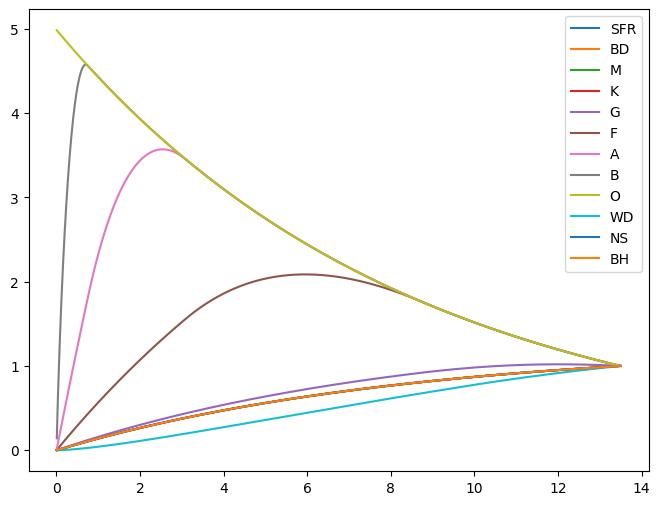

In [23]:
star_types = {
    'O': (16, 100),
    'B': (2.1, 16),
    'A': (1.4, 2.1),
    'F': (1.04, 1.4),
    'G': (0.8, 1.04),
    'K': (0.45, 0.8),
    'M': (0.1, 0.45),
    'BH': (20, 100),      # https://en.wikipedia.org/wiki/Black_hole (5-100)
                          # https://en.wikipedia.org/wiki/Supermassive_black_hole
    'NS': (8, 20),        # https://en.wikipedia.org/wiki/Neutron_star (0.7-2.5)
    'WD': (1, 8),         # 0.17-1.4 (https://en.wikipedia.org/wiki/White_dwarf) peaked at 0.6-0.7
    'BD': (0.01, 0.08)  
}

import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import scipy.integrate
from scipy.special import betainc
from scipy.special import hyp2f1
import scipy.special

# -----------------------------
# 1.  Parameters (same as above)
# -----------------------------
tau      = 2          # τ  (Gyr)
alpha    = 30          # α
beta     = 2          # β
delta    = 2.5          # δ
mc       = 0.2       # m_c (M⊙)
sigma    = 0.55         # σ
alpha_IMF = 2.3         # α_IMF
T_final = 13.5          # Gyr

# -----------------------------
# 2.  Helper functions
# -----------------------------


# def CSFR(t0):
#     return np.where(t0 <= 0.0, 0, my_SFR(t0)-my_SFR(0))  # Choudhury & Ferrara 2006

CSFR = lambda t: CSFR_DICTIONARY["exponential"](t)
#def CSFR(t):
#    return (1 - np.exp(-t/8.4)) / (1 - np.exp(-T_final/8.4)) * np.heaviside(t,0)    # Choudhury & Ferrara 2006

#def CSFR(t):
#    return np.heaviside(t,0)

kappa = (1.0/(np.sqrt(2*np.pi)*sigma)) \
        * np.exp(-(np.log(1.0/mc))**2/(2.0*sigma**2))  # continuity factor

def xi(m):
    """Chabrier IMF ξ(m)."""
    log_norm = (1.0/(m*np.sqrt(2*np.pi)*sigma)) \
               * np.exp(-np.log(m/mc)**2/(2.0*sigma**2))
    powerlaw = kappa * m**(-alpha_IMF)
    return np.where(m <= 1.0, log_norm, powerlaw)

m_cut = delta*np.log(T_final)-1
print(m_cut)

def tau_star(m):
    """
    Vrací přibližnou dobu životnosti hlavní posloupnosti (v Gyr)
    podle přibližného předpisu:
      - 10 * m^(-2.5) pro m < 1 M_solar
      - 10 * m^(-3.5) pro m >= 1 M_solar
    """
    m = np.asarray(m)
    return np.where(m < 1.0, 10 * m**-2.5, 10 * m**-3.5)

def SCHunnormed(m, t0):
    CSFR_now = CSFR(t0)
    CSFR_prev = CSFR(t0-tau_star(m))
    return xi(m) * (CSFR_now - CSFR_prev)

def SCHnormed(m, t0, xi_integral=1, remnants=False):
    # tau_star = 10.0 * m**(-delta)
    CSFR_prev = CSFR(t0 - tau_star(m))
    if remnants:
        res = xi(m) * (CSFR_prev-CSFR(0))/xi_integral * np.heaviside(t0-tau_star(m),1)
        return res
    else:
        CSFR_now = CSFR(t0)
        return xi(m) * (CSFR_now - CSFR_prev) / xi_integral

T0 = 13.5
  # integrate over
stars = {}
stars_params = {}
order = ['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O', 'WD', 'NS', 'BH']

for key in order:
    if key in ["BH", "NS", "WD"]:
        remn = True
    else:
        remn = False
    mL, mU = star_types[key]
    t_num, m_num = 1000, 1000
    m_vals = np.linspace(mL, mU, m_num+1, endpoint=True, dtype=np.float64)
    t_vals = np.linspace(0.0, T_final, t_num+1, endpoint=True, dtype=np.float64)
    m_centers = 0.5*(m_vals[:-1] + m_vals[1:])  # cell centres for the integrand
    t_centers = 0.5*(t_vals[:-1] + t_vals[1:])  # cell centres for the integrand
    dm = np.diff(m_vals)
    dt = np.diff(t_vals)
    M, T = np.meshgrid(m_centers, t_centers, indexing='xy')   # shapes (nt, nm)
    xi_integral = scipy.integrate.quad(xi, mL, mU)[0]  # integral of xi(m) over m
    SCH_grid = SCHnormed(M, T, remnants=remn, xi_integral=1)  # shape (nt, nm)
    counts_in_row = np.sum(SCH_grid,axis=1) # integrate over m
    Z = counts_in_row[-1]
    print("Normalisation factor:", Z)
    counts_in_row = counts_in_row/counts_in_row[-1] # normalize last row to 1
    count_mean = np.sum(counts_in_row)*dt[0]/T_final # mean of the sum of the normalized counts (should be 0.64 if m > m_cut)
    stars[key] = {'m': m_vals, 't': t_vals, 'SCH': SCH_grid/counts_in_row[-1]*dm[0]}
    stars_params[key] = {'mean': count_mean, 'counts_in_row': counts_in_row, 'm_vals': m_vals, 't_vals': t_vals, 'SCH_grid': SCH_grid/counts_in_row[-1]*dm[0]}
    print(f"This is {key} mean count: {count_mean}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t_centers, CSFR(t_centers), label='SFR')
print(list(stars_params.keys()))
#if key in list(stars_params.keys()):
for key in stars_params.keys():
    stars_params[key]['m_vals'] = m_vals
    stars_params[key]['t_vals'] = t_vals
    vals = stars_params[key]['counts_in_row']
    if key in ['WD', 'BH', 'NS']:
        ax.plot(t_centers, vals, label=key)
    elif key not in ['BH', 'NS', 'WD']:
        ax.plot(t_centers, vals, label=key)
ax.legend()
plt.show()


In [24]:
from matplotlib import cm
from matplotlib.colors import Normalize

target_counts = {
    # https://www.aanda.org/articles/aa/pdf/2023/06/aa43919-22.pdf
    'O': 5e-7,    
    'B': 3.9e-4,
    'A': 6.0e-3,
    'F': 0.031,
    'G': 0.059,
    'K': 0.129,
    'M': 0.725,
}

print(np.sum(list(target_counts.values())))

remnants = {
    'BH': 1e8, # https://www.aanda.org/articles/aa/pdf/2020/06/aa36557-19.pdf
    'NS': 1e8, # https://www.aanda.org/articles/aa/pdf/2010/02/aa12222-09.pdf
    'WD': 11.5e9, # https://iopscience.iop.org/article/10.1088/1742-6596/172/1/012004/pdf
    'BD': 1e11} 

N = 400e9
N_remnants = np.sum(list(remnants.values()))
N_stars = N - N_remnants
N_counts = {k : N * v for k, v in target_counts.items()}
N_counts.update(remnants)

0.9503904999999999


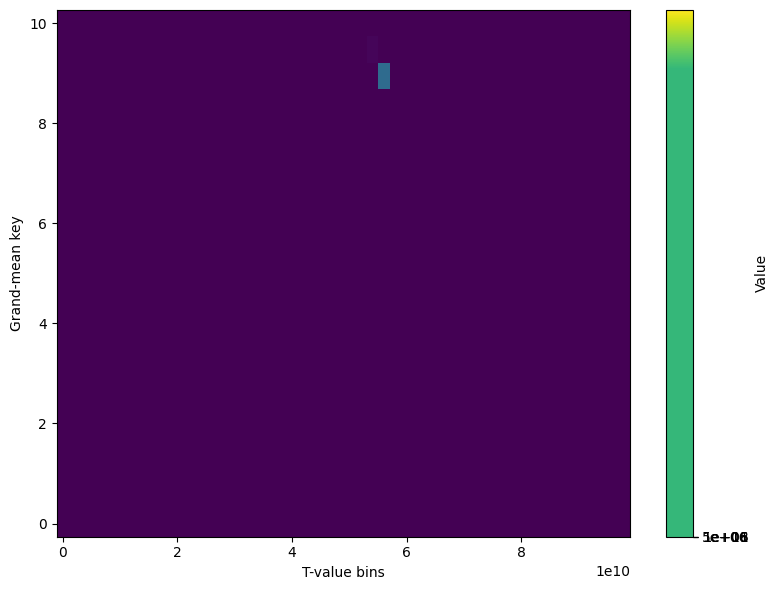

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class CustomBreakNorm(Normalize):
    """
    Piecewise‐linear Normalize that:
      - breaks at the user’s `breaks` values,
      - allocates equal colorbar length to each interval,
      - is linear *within* each interval.
    """
    def __init__(self, breaks, clip=False):
        """
        breaks : sorted list or array of break‐values [v0, v1, …, vN]
        clip   : whether to clip values outside [v0,vN]
        """
        breaks = np.array(breaks, dtype=float)
        super().__init__(vmin=breaks[0], vmax=breaks[-1], clip=clip)
        self.breaks   = breaks
        self.nint     = len(breaks) - 1
        # each interval gets 1/nint of the colorbar
        self.frac     = np.ones(self.nint) / self.nint
        self.cumfrac  = np.concatenate(([0], np.cumsum(self.frac)))

    def __call__(self, x, clip=None):
        x = np.array(x, copy=False)
        out = np.zeros_like(x, dtype=float)
        # map each interval linearly into its slice
        for i in range(self.nint):
            lo, hi = self.breaks[i], self.breaks[i+1]
            mask   = (x >= lo) & (x <= hi)
            f0, f1 = self.cumfrac[i], self.cumfrac[i+1]
            out[mask] = f0 + (x[mask] - lo) / (hi - lo) * (f1 - f0)
        # clamp under/over values
        out[x < self.breaks[0]] = 0.0
        out[x > self.breaks[-1]] = 1.0
        return out

# --- Replace these with your actual data ---
# hist_tvals: 1D array of bin edges (length M+1)
# grand_mean: dict mapping Y-values to 1D arrays (length M)
# For demonstration, here’s dummy data:
hist_tvals = np.linspace(0, 1, 51) * 1e11  # 50 bins from 0 to 1e11
ys = np.linspace(0, 10, 20)                # 20 different “rows”
grand_mean = {y: np.random.lognormal(8, 2, len(hist_tvals)-1) for y in ys}
# ------------------------------------------

# 1) Choose your break‐points:
breaks = [1e6, 5e6, 1e8, 1e11]
norm   = CustomBreakNorm(breaks)

# 2) Build the 2D array for pcolormesh:
X = hist_tvals[:-1]
Y = np.array(list(grand_mean.keys()))
Z = np.vstack(list(grand_mean.values()))

# 3) Plot:
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(X, Y, Z, cmap='viridis', norm=norm)
cb = fig.colorbar(mesh, ax=ax)

# 4) Evenly space ticks & label them at your breaks:
n = len(breaks) - 1
tick_locs   = np.linspace(0, 1, n+1)
tick_labels = [f"{b:.0e}" for b in breaks]
cb.set_ticks(tick_locs)
cb.set_ticklabels(tick_labels)
cb.set_label("Value")

ax.set_xlabel("T-value bins")
ax.set_ylabel("Grand-mean key")
plt.tight_layout()
plt.show()


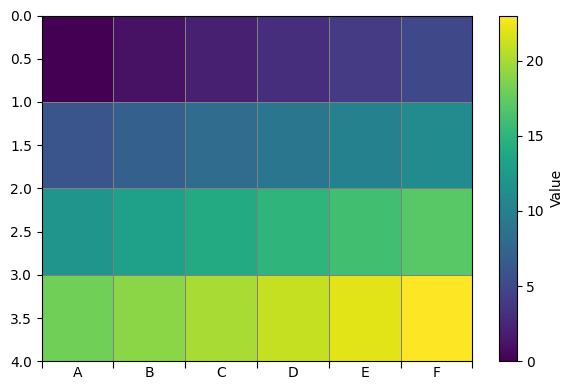

In [228]:
import numpy as np
import matplotlib.pyplot as plt

# dummy data
data = np.arange(6*4).reshape(4,6)
col_names = list("ABCDEF")

fig, ax = plt.subplots(figsize=(6, 4))
mesh = ax.pcolormesh(data, edgecolors='grey', linewidth=0.5)

# number of columns
ncols = data.shape[1]

# 1) Major ticks at the cell *edges* (0,1,2,...,ncols), no labels
ax.set_xticks(np.arange(ncols+1), minor=False)
ax.set_xticklabels([])
ax.xaxis.set_tick_params(which='major', length=5)   # tick mark length
#  (you can tweak length, width, etc.)

# 2) Minor ticks at the cell *centers* (.5,1.5,...,ncols-0.5), with labels
centers = np.arange(ncols) + 0.5
ax.set_xticks(centers, minor=True)
ax.set_xticklabels(col_names, minor=True)
ax.xaxis.set_tick_params(which='minor', length=0)   # hide the minor tick marks
ax.xaxis.set_tick_params(which='minor', labelsize=10)

# 3) If you inverted y before, restore or adjust as needed
ax.invert_yaxis()

fig.colorbar(mesh, ax=ax, label='Value')
plt.tight_layout()
plt.show()


In [ ]:
import math

class LatexFloat(float):
    def __format__(self, spec: str) -> str:
        # If the spec ends with 'L', do our LaTeX‐scientific formatting
        if spec.endswith("L"):
            # strip the 'L'
            sig_spec = spec[:-1]
            # parse number of significant figures (default 1)
            if sig_spec.startswith("."):
                sig = int(sig_spec[1:])
            elif sig_spec:
                sig = int(sig_spec)
            else:
                sig = 1

            x = self
            if x == 0:
                mant, exp = 0, 0
            else:
                exp = math.floor(math.log10(abs(x)))
                mant = x / (10 ** exp)

            # we want (sig-1) decimals after the comma
            decs = max(sig - 1, 0)
            mant_str = f"{mant:.{decs}f}".replace(".", ",")

            # return *just* the LaTeX snippet—no dollar signs
            return f"${mant_str}\\cdot10^{{{exp}}}$"
        # otherwise, fall back to normal float formatting
        return super().__format__(spec)

x = LatexFloat(11230)
print(f"{x:.4L}")   # → 1,123\cdot10^{4}

y = LatexFloat(0.005678)
print(f"{y:.3L}")   # → 5,68\cdot10^{-3}

z = LatexFloat(0)
print(f"{z:.5L}")   # → 0\cdot10^{0}


ModuleNotFoundError: No module named 'macropy'

5.339994201060095 11.45204460259979
['BD', 'M', 'K', 'G', 'F', 'A', 'B', 'O']
[0.01, 0.1, 0.45, 0.8, 1.04, 1.4, 2.1, 16, 100]
100


C:\Users\adamc\AppData\Local\Temp\ipykernel_17924\2809651017.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  secax.xaxis.set_ticklabels(second_labels, minor=False)


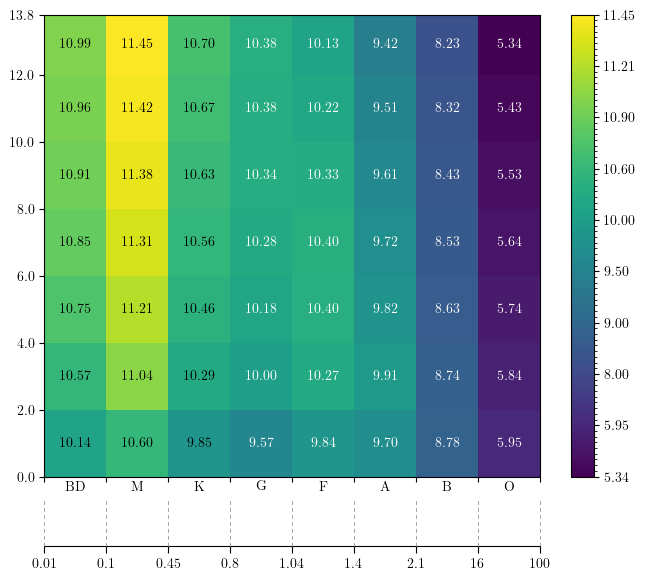

In [309]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from IPython.display import display, Markdown

import graphpackage as gp

gp.useLatex()

heatmap = np.array([])
hist_tvals = np.array([0,2,4, 6, 8, 10,  12, 13.8])
# hist_tvals = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13, 13.8])

t_vals = stars_params['O']['t_vals']
t_args = []
for i in range(len(hist_tvals) - 1):
    low  = hist_tvals[i]
    high = hist_tvals[i+1]
    # boolean mask: t_vals >= low  AND t_vals < high
    mask = (t_vals >= low) & (t_vals < high)
    idxs = np.where(mask)[0]           # get 1D array of indices
    t_args.extend(idxs) 
    
grand_mean = {}
for key in stars_params.keys():
    small_mean = []
    for i in range(1, len(hist_tvals)):
        t_vals = stars_params[key]['t_vals']
        indices = np.digitize(t_vals[:-1], hist_tvals)
        args = np.argwhere(indices == i)
        small_mean.append(np.mean(stars_params[key]['counts_in_row'][args]))
    grand_mean[key] =  np.array(small_mean)*N_counts[key]

keys = list(grand_mean.keys())
remnants = ['BH', 'NS', 'WD']
for key in remnants:
    if key in keys:
        keys.remove(key)
        
data = np.log10(np.array([grand_mean[key] for key in keys]))

vmin, vmax = data.min(), data.max()
print(vmin, vmax)



interiors = [np.log10(grand_mean['O'].max()), 8,9,9.5, 10, np.log10(grand_mean['M'].min()), 10.9, np.log10((grand_mean['M'].min()+grand_mean['M'].max())*0.5)]  # breakpoints in the data

A = np.concatenate(([vmin], interiors, [vmax]))
levels = np.linspace(0, 1, len(A),endpoint=True)  # [0, 1] for n+2 points
# forward: data→[0,1]; inverse: [0,1]→data
forward = lambda x: np.interp(x, A, levels)
inverse = lambda x: np.interp(x, levels, A)
norm = mcolors.FuncNorm((forward,inverse))


fig, ax = plt.subplots(figsize=(8,6))
T_edges = hist_tvals
Y_edges = np.arange(len(keys) + 1)
pcm = ax.pcolormesh(Y_edges, T_edges, data.T, norm=norm)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_ticks(A)  # set ticks at the breakpoints
cbar.ax.minorticks_on()
min_positions = [np.linspace(A[i], A[i+1], 10)[1:] for i in range(len(A)-1)]
minor_positions = np.array(min_positions).flatten()
cbar.set_ticks(minor_positions, minor=True)
#cbar.set_ticklabels([f"{LatexFloat(x):.3L}" for x in A])
cbar.set_ticklabels([f"{x:.2f}" for x in A])
cbar._minor_ticks = cbar.ax.yaxis.get_minor_ticks()
for tick in cbar._minor_ticks:
    tick.tick1line.set_markersize(4)
    
T_centers = 0.5*(T_edges[:-1] + T_edges[1:])
Y_centers = 0.5*(Y_edges[:-1] + Y_edges[1:])    

n_Y, n_T = data.shape


colors = ['black', 'black', 'black', 'white', 'white', 'white', 'white', 'white']
for i in range(n_T):         # i indexes T_centers (the y‐positions)
    for j in range(n_Y):     # j indexes Y_centers (the x‐positions)
        ax.text(
            Y_centers[j],    # x‐coordinate
            T_centers[i],    # y‐coordinate
            f"{data[j, i]:.2f}",  # your label; format as you like
            ha="center", va="center", color=colors[j]
        )

centers = np.arange(len(Y_edges)-1) + 0.5
ax.set_xticks(centers, minor=True)
ax.set_xticklabels(keys, minor=True)
ax.xaxis.set_tick_params(which='minor', length=0)   # hide the minor tick marks
ax.xaxis.set_tick_params(which='minor', labelsize=10)
ax.xaxis.set_ticklabels([])   # tick mark length

secax = ax.secondary_xaxis(-0.15, functions=(lambda x: x, lambda x: x))
# only show the bottom spine/ticks
secax.spines['top'].set_visible(False)
secax.spines['right'].set_visible(False)
secax.spines['left'].set_visible(False)
secax.xaxis.set_tick_params(which='major', length=5)

# use exactly the same centers – but with different labels
print(keys)
second_labels = [list(star_types[name])[0] for name in keys]
second_labels.extend([list(star_types['O'])[1]])
print(second_labels)
print(list(star_types['O'])[1])
secax.xaxis.set_ticklabels(second_labels, minor=False)
secax.grid(True, which='major', color='lightgray', alpha=0.5)
# secax.spines['bottom'].set_position(('outward', 5))

tick_positions = ax.get_xticks()
lines = ax.vlines(
    tick_positions,
    ymin=-0.15,
    ymax=-0.05,
    transform=ax.get_xaxis_transform(),
    linewidth=0.5,
    linestyles=(0,(5,5)),
    colors='gray',
    clip_on=False
)

ytick_positions = ax.get_yticks()
ytick_positions[-1] = 13.8
ax.set_yticks(ytick_positions, minor=False)

lines.set_capstyle('round')
lines.set_joinstyle('round')

plt.show()

In [ ]:
vmin = 1e6
vmax = 1e11
interiors = np.linspace(vmin, vmax, n+2)[1:-1]  # n points strictly inside
A = np.concatenate(([vmin], interiors, [vmax]))
levels = np.linspace(0, 1, len(A), endpoint=True)  # [0, 1] for n+2 points

print(levels)
print(A)
def length(x):
    """Length of the interval [x[0], x[-1]]"""
    return x[-1] - x[0]

def normal(x, A, levels, forward=True):
    if forward:
        # x, y
        # levels (x_values) are mapped to [0, 1]
        res = np.interp(x, levels, A),
    else:
        res = np.interp(x, , A)
    return res

# x y 
print(normal(A, levels, A, forward=True))

[0.   0.25 0.5  0.75 1.  ]
[1.000000e+06 2.500075e+10 5.000050e+10 7.500025e+10 1.000000e+11]
[1.000000e+06 2.500075e+10 5.000050e+10 7.500025e+10 1.000000e+11]


In [2]:
nx, ny = 200, 200

# 1D coordinate vectors
x = np.linspace(0, 10, nx)
y = np.linspace(0, 10, ny)

# 2D meshgrid
X, Y = np.meshgrid(x, y)

# normalized “pattern” in [0,1]
# here we use a simple product so values run from 0 at (0,0) to 1 at (10,10)
Z = (X/10) * (Y/10)

# scale to [vmin, vmax]
data = vmin + (vmax - vmin) * Z

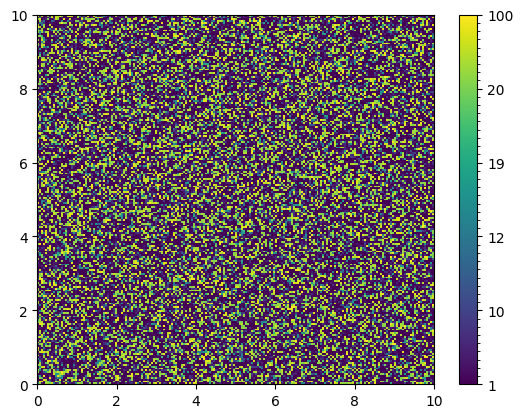

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker


# your existing setup
vmin, vmax = 1, 100
n = 5  # for example
interiors = [10,12,19,20]
A = np.concatenate(([vmin], interiors, [vmax]))
levels = np.linspace(0, 1, len(A),endpoint=True)  # [0, 1] for n+2 points

# forward: data→[0,1]; inverse: [0,1]→data
forward = lambda x: np.interp(x, A, levels)
inverse = lambda x: np.interp(x, levels, A)

# build the FuncNorm
norm = mcolors.FuncNorm((forward,inverse))

data = np.power(np.random.rand(len(X)-1, len(Y)-1),5)* (vmax - vmin) + vmin  # example data

# then use it in any mappable
fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, data, cmap='viridis', norm=norm)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_ticks(A)  # set ticks at the breakpoints
cbar.ax.minorticks_on()
min_positions = [np.linspace(A[i], A[i+1], )[1:] for i in range(len(A)-1)]
minor_positions = np.array(min_positions).flatten()
cbar.set_ticks(minor_positions, minor=True)
cbar._minor_ticks = cbar.ax.yaxis.get_minor_ticks()
for tick in cbar._minor_ticks:
    tick.tick1line.set_markersize(4)

plt.show()


<bound method YAxis.set of <matplotlib.axis.YAxis object at 0x00000277DF373B00>>

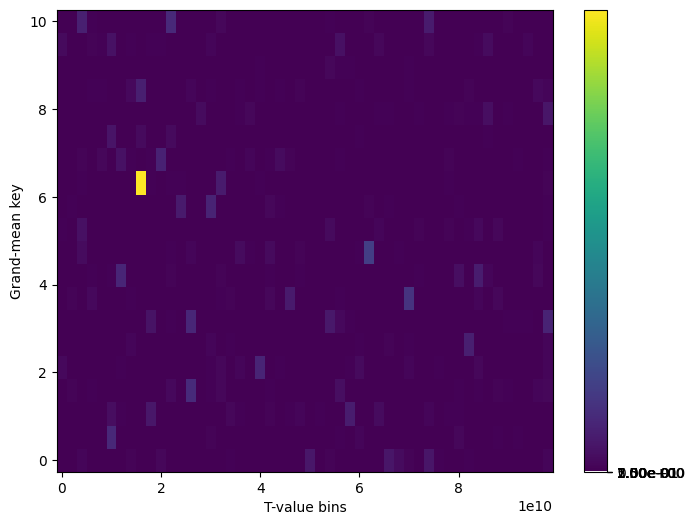

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import FuncNorm
from matplotlib.cm import ScalarMappable

# --- Dummy data (replace with yours) ---
hist_tvals = np.linspace(0, 1, 51) * 1e11
ys         = np.linspace(0, 10, 20)
grand_mean = {y: np.random.lognormal(8, 2, len(hist_tvals)-1) for y in ys}
X = hist_tvals[:-1]
Y = np.array(list(grand_mean.keys()))
Z = np.vstack(list(grand_mean.values()))
# ----------------------------------------

# 1) find vmin, vmax
vmin, vmax = Z.min(), Z.max()

# 2) pick n interior points (e.g. n=3) and build A = [vmin, ... interior ..., vmax]
n = 3
interiors = np.linspace(vmin, vmax, n+2)[1:-1]  # n points strictly inside
A = np.concatenate(([vmin], interiors, [vmax]))
# now len(A) == n+2

# 3) build normalized levels *exactly* equidistant in [0,1]
levels = np.linspace(0, 1, len(A))   # e.g. [0, 0.25, 0.5, 0.75, 1] for n=3


# 4) make a FuncNorm that linearly interpolates between (A[i] ↔ levels[i])
norm = FuncNorm(
        (
        )



# 5) plot your mesh with shading='auto'
fig, ax = plt.subplots(figsize=(8,6))
mesh = ax.pcolormesh(X, Y, Z, cmap='viridis', norm=norm, shading='auto')
ax.set_xlabel("T-value bins")
ax.set_ylabel("Grand-mean key")

# 6) draw a standalone continuous colorbar
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])
cb = fig.colorbar(sm, ax=ax)
cb.solids.set_edgecolor("face")  # remove patch edges
cb.solids.set_linewidth(0)

# 7) overlay white separator lines at the internal levels
for lev in levels[1:-1]:
    cb.ax.hlines(lev, *cb.ax.get_xlim(), color='white', linewidth=2)

# 8) place ticks *exactly* at those levels (they are equidistant by construction)
cb.set_ticks(levels)
cb.set_ticklabels([f"{val:.2e}" for val in levels])
cb.ax.yaxis.set


In [ ]:
heatmap = np.array([])
hist_tvals = np.array([0,1,2,3,4,5, 6, 7, 8, 9, 10, 11, 12, 13, 13.8])
t_vals = stars_params['O']['t_vals']
t_args = np.array([])
for i, t in enumerate(hist_tvals):
    argsA = np.argwhere(hist_tvals[i] == t_vals)
    print(argsA)
    argsB = np.argwhere(hist_tvals[i] > t_vals)
    
    
grand_mean = {}
for key in stars_params.keys():
    small_mean = []
    for i in range(1, len(hist_tvals)):
        # Get the data for the current key
        t_vals = stars_params[key]['t_vals']
        # Get the indices of the bins
        indices = np.digitize(t_vals[:-1], hist_tvals)
        # Get the values in the current bin
        args = np.argwhere(indices == i)
        small_mean.append(np.mean(stars_params[key]['counts_in_row'][args]))
    grand_mean[key] =  np.array(small_mean)*N_counts[key]

data = np.array(list(grand_mean.values()))


from matplotlib.colors import SymLogNorm, PowerNorm, LogNorm
fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(hist_tvals[:-1], grand_mean.keys(), grand_mean.values(), cmap='viridis', norm=norm)
cb = ax.figure.colorbar(ax.collections[0], ax=ax, orientation='vertical')


[[0]]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
{'BD': array([7.24533715e+09, 2.05456328e+10, 3.22688568e+10, 4.26775699e+10,
       5.19191666e+10, 6.01245144e+10, 6.74098066e+10, 7.38782078e+10,
       7.96213150e+10, 8.47204546e+10, 8.92478340e+10, 9.32675637e+10,
       9.68365661e+10, 9.92595710e+10]), 'M': array([2.10114777e+10, 5.95823352e+10, 9.35796846e+10, 1.23764953e+11,
       1.50565583e+11, 1.74361092e+11, 1.95488439e+11, 2.14246803e+11,
       2.30901814e+11, 2.45689318e+11, 2.58818718e+11, 2.70475935e+11,
       2.80826042e+11, 2.87852756e+11]), 'K': array([3.73859397e+09, 1.06015465e+10, 1.66507301e+10, 2.20216261e+10,
       2.67902900e+10, 3.10242494e+10, 3.47834602e+10, 3.81211552e+10,
       4.10845985e+10, 4.37157546e+10, 4.60518823e+10, 4.81260629e+10,
       4.99676681e+10, 5.12179387e+10]), 'G': array([1.94496784e+09, 5.51535342e+09, 8.66238343e+09, 1.14565408e+10,
       1.39373927e+10, 1.61400697e+10, 1.80957632e+10, 1.98321672e+10,
       2.13727962e+10, 2.2

NameError: name 'CustomBreakNorm' is not defined

[1.0000e-02 1.0070e-02 1.0140e-02 ... 9.9748e+01 9.9832e+01 9.9916e+01]


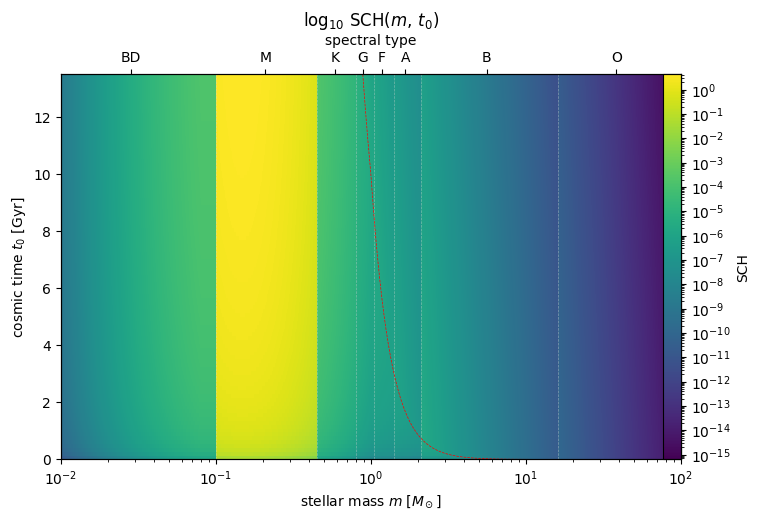

In [169]:
def minmax(n):
    return np.min(n), np.max(n)
m_edges = np.concatenate([stars[k]['m'][:-1] for k in order if not k in ['BH', 'NS', 'WD']])
m_hline_edges = [stars[k]['m'][0] for k in order if not k in ['BH', 'NS', 'WD']]
m_hline_edges = np.append(m_hline_edges, [100])
m_ticks_centres = [
    10**(0.5*np.log10(stars[k]['m'][0]) + 0.5*np.log10(stars[k]['m'][-1]))
    for k in order if not k in ['BH', 'NS', 'WD']]

SCH = np.column_stack([stars[k]['SCH'] for k in order if not k in ['BH', 'NS', 'WD']])             # shape (nt-1, 8*(nm-1)))))

fig, ax = plt.subplots(figsize=(8, 5))
extent = [min(m_edges), max(m_edges), 0.0, T_final]
import matplotlib as mpl
pcm = ax.pcolormesh(np.append(m_edges, max(m_edges)), t_vals, SCH, shading='auto', norm=mpl.colors.SymLogNorm(linthresh=1e-16))

print(m_edges)

ax.vlines(m_hline_edges, 0, T_final, color='lightgray', linestyle='--', lw=0.5, alpha=0.5)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)     # tie the divider to *ax*’s figure
cax = divider.append_axes("right",    # where to put the bar
                          size="3%",  # width (or height) of the bar
                          pad=0.1)    # space between plot and bar

x_deathCurve = np.linspace((10/13.5)**(1/delta), 100, 100000)
y_deathCurve = tau_star(x_deathCurve)

ax.plot(x_deathCurve, y_deathCurve, color='red', linestyle='--', lw=0.5)

cb = fig.colorbar(pcm, cax=cax)
vmin, vmax  = 0, SCH.max()
norm        = mpl.colors.PowerNorm(gamma=0.05, vmin=vmin, vmax=vmax)
ticks_norm   = np.linspace(0, 1, 10)       # 0 … 1 evenly spaced
ticks_data   = norm.inverse(ticks_norm)

def sci_label(val, _):
    """Return 'mantissa × 10**exponent' (handles val = 0)."""
    if val == 0:
        return "0"
    exp  = int(np.floor(np.log10(abs(val))))
    mant = val / 10**exp
    return rf"${mant:.2g} \cdot 10^"+"{"+f"{exp}"+"}$"

cb.set_label('SCH')
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import SymmetricalLogLocator

norm = mpl.colors.SymLogNorm(linthresh=1e-16, vmin=0, vmax=SCH.max())
cb.ax.yaxis.set_minor_locator(
    SymmetricalLogLocator(
        linthresh=norm.linthresh,  # match your SymLogNorm settings
        base=10,                   # base (default 10 unless you changed it)
        subs=[2, 3, 4, 5, 6, 7, 8, 9],  # typical minor ticks between decades
    )
)

axt = ax.twiny()
axt.set_xscale('log')
axt.set_xticks(m_ticks_centres)
axt.set_xticklabels([key for key in order if not key in ['BH', 'NS', 'WD']])
axt.set_xlabel('spectral type')
axt.set_xlim(ax.get_xlim())

log_ticks = np.log10([0.01, 0.1, 1, 10, 100])


ax.set_xticks(log_ticks)
ax.set_xticklabels([0.01, 0.1, 1, 10, 100])
ax.set_xscale('log')
ax.set_xlim(0.01, 100)

ax.set_xlabel(r"stellar mass $m \;[M_\odot]$")
ax.set_ylabel(r"cosmic time $t_0$ [Gyr]")
ax.set_title(r"$\log_{10}\,{\rm SCH}(m,\,t_0)$")
axt.minorticks_off()


In [225]:
def SCHnormed(m, t0, xi_integral=1, remnants=False):
    # tau_star = 10.0 * m**(-delta)
    CSFR_prev = CSFR(t0 - tau_star(m))
    if remnants:
        res = (CSFR_prev-CSFR(0))/xi_integral * np.heaviside(t0-tau_star(m),1)
        return res
    else:
        CSFR_now = CSFR(t0)
        return (CSFR_now - CSFR_prev)

(1000, 1001)
(1000, 1001) (1000, 1001)


C:\Users\adamc\AppData\Local\Temp\ipykernel_15692\916143493.py:10: RuntimeWarning: invalid value encountered in divide
  mass_unnormed = mass_unnormed/mass_unnormed[:,-1][:,np.newaxis]


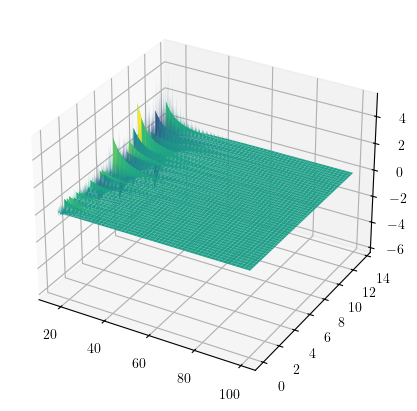

In [226]:
mass = stars_params['O']['m_vals']
mass_centers = (stars_params['O']['m_vals'][:-1] + stars_params['O']['m_vals'][1:])*0.5
mass_unnormed = stars_params['O']['SCH_grid']/xi_new[np.newaxis,:]
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': '3d'})
t = stars_params['O']['t_vals']
t_centers = (t[:-1] + t[1:])*0.5
M, T = np.meshgrid(stars_params['O']['m_vals'], stars_params['O']['t_vals'], indexing='xy')   # shapes (nt, nm)

mass_unnormed = SCHnormed(M, T, remnants=False)
mass_unnormed = mass_unnormed/mass_unnormed[:,-1][:,np.newaxis]

M, T = np.meshgrid(mass, t_centers, indexing='xy')   # shapes (nt, nm)
print(np.diff(mass_unnormed,axis=0).shape)
print(M.shape, T.shape)
ax.plot_surface(M,  T, np.diff(mass_unnormed,axis=0), cmap='viridis', edgecolor='none')

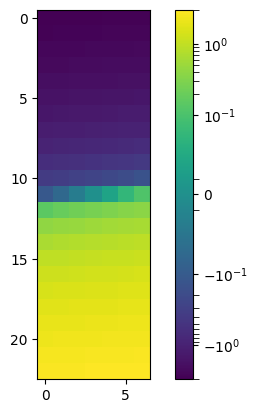

In [170]:
from matplotlib.ticker import Locator, SymmetricalLogLocator, MultipleLocator
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

class MinorSymLogLocator(Locator):
    """Minor ticks for a symlog axis."""
    def __init__(self, linthresh, nints=10):
        self.linthresh  = float(linthresh)
        self.nintervals = int(nints)

    def __call__(self):
        maj = np.asarray(self.axis.get_majorticklocs())
        if maj.size < 2:
            return self.raise_if_exceeds(np.array([]))

        # fill a virtual major either side so we cover the whole data range
        dm_low, dm_up = maj[1]-maj[0], maj[-1]-maj[-2]
        maj = np.insert(maj,  0, maj[0]-dm_low)
        maj = np.append(maj, maj[-1]+dm_up)

        minor = []
        for lo, hi in zip(maj[:-1], maj[1:]):
            step = (hi-lo) / (self.nintervals if abs((lo+hi)/2) < self.linthresh
                                               else self.nintervals-1)
            minor.extend(np.arange(lo+step, hi, step))
        return self.raise_if_exceeds(np.asarray(minor))

    def tick_values(self, vmin, vmax):          # required by matplotlib
        self.axis = type("dummy", (), dict(get_majorticklocs=lambda *a: [vmin, vmax]))
        return self()

class MinorSymLogLocator(Locator):
    """
    Minor ticks for a symlog axis:
      • inside |x| < linthresh the distance is linear and split into *nints*
        equal intervals  →  nints-1 minor ticks.
      • outside that region normal log-minor ticks are taken from
        SymmetricalLogLocator(subs=2…9).
    """
    def __init__(self, linthresh, nints=4, base=10, subs=range(2,10)):
        self.linthresh  = float(linthresh)
        self.nints      = int(nints)           # 4 ⇒ 3 minor ticks
        self._logminor  = mticker.SymmetricalLogLocator(linthresh, base, subs)

    # ------------------------------------------------------------------
    def _linear_minor(self, majors):
        """evenly spaced ticks between majors inside the linear part"""
        minors = []
        for lo, hi in zip(majors[:-1], majors[1:]):
            if abs((lo+hi)/2) < self.linthresh:        # this segment is linear
                step = (hi-lo) / self.nints            # nints intervals ⇒ nints-1 ticks
                minors.extend(np.arange(lo+step, hi, step))
        return minors

    # ------------------------------------------------------------------
    def __call__(self):
        vmin, vmax   = self.axis.get_view_interval()
        majors       = self.axis.get_majorticklocs()
        minor_log    = self._logminor.tick_values(vmin, vmax)   # outside ±linthresh
        minor_linear = self._linear_minor(majors)

        ticks = np.unique(np.concatenate([minor_log, minor_linear]))
        ticks = ticks[np.isfinite(ticks)]                        # safety
        return self.raise_if_exceeds(ticks)

    # required by Matplotlib’s API
    def tick_values(self, vmin, vmax):
        self.axis = type("dummy", (), dict(get_view_interval=lambda: (vmin, vmax),
                                           get_majorticklocs=lambda: np.array([-self.linthresh, 0., self.linthresh])))
        return self()
    
    
import numpy as np
import matplotlib.ticker as mticker
from matplotlib.ticker import Locator

class MinorSymLogLocator(Locator):
    """
    Minor ticks for a symlog axis:
      • inside |x| < linthresh the distance is linear and split into nints
        equal intervals  →  nints-1 minor ticks.
      • outside that region normal log‐minor ticks are taken from
        SymmetricalLogLocator(subs=range(2,10)).
    """

    def __init__(self, linthresh, nints=4, base=10, subs=range(2,10)):
        self.linthresh  = float(linthresh)
        self.nints      = int(nints)
        # ← here use keywords, not positional:
        self._logminor  = mticker.SymmetricalLogLocator(
                               linthresh=self.linthresh,
                               base=base,
                               subs=subs)

    def _linear_minor(self, majors):
        minors = []
        for lo, hi in zip(majors[:-1], majors[1:]):
            if abs((lo+hi)/2) < self.linthresh:
                step = (hi - lo) / self.nints
                minors.extend(np.arange(lo + step, hi, step))
        return minors

    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        majors     = self.axis.get_majorticklocs()

        minor_log    = self._logminor.tick_values(vmin, vmax)
        minor_linear = self._linear_minor(majors)

        ticks = np.unique(np.concatenate([minor_log, minor_linear]))
        return self.raise_if_exceeds(ticks)

    def tick_values(self, vmin, vmax):
        # fallback for autoscaling
        self.axis = type("dummy", (), {
            "get_view_interval":   lambda *a: (vmin, vmax),
            "get_majorticklocs":   lambda *a: np.array([-self.linthresh, 0., self.linthresh])
        })
        return self()

import numpy as np
import matplotlib.ticker as mticker
from matplotlib.ticker import Locator

class MinorSymLogLocator(Locator):
    """
    Minor ticks for a symlog axis or colorbar:

      • Inside |x| < linthresh we place exactly `n_sub` linear ticks,
        equally spaced between each pair of major ticks.
      • Outside that region we defer to SymmetricalLogLocator(subs=2…9)
        to get the usual decades-subdivisions.
    """
    def __init__(self, linthresh, n_sub=4, base=10, subs=range(2,10)):
        self.linthresh = float(linthresh)
        self.n_sub     = int(n_sub)
        # for the log-regions
        self._logminor = mticker.SymmetricalLogLocator(
                             linthresh=self.linthresh,
                             base=base,
                             subs=subs)

    def _linear_minor(self, majors):
        out = []
        # walk each gap of the major ticks:
        for lo, hi in zip(majors[:-1], majors[1:]):
            mid = 0.5*(lo+hi)
            if abs(mid) < self.linthresh:
                # n_sub ticks ⇒ n_sub+1 intervals
                step = (hi - lo) / (self.n_sub + 1)
                for k in range(1, self.n_sub + 1):
                    out.append(lo + k*step)
        return out

    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        majors     = self.axis.get_majorticklocs()

        # outside ±linthresh → log minors
        minors_log = self._logminor.tick_values(vmin, vmax)
        # inside ±linthresh → linear minors
        minors_lin = self._linear_minor(majors)

        all_minor = np.unique(np.concatenate([minors_log, minors_lin]))
        return self.raise_if_exceeds(all_minor)

    def tick_values(self, vmin, vmax):
        # fallback for autoscale:
        self.axis = type("dummy", (), dict(
            get_view_interval   = lambda *a: (vmin, vmax),
            get_majorticklocs   = lambda *a: np.array(
                                     [-self.linthresh, 0., self.linthresh])
        ))
        return self()


import numpy as np
import matplotlib.ticker as mticker
from matplotlib.ticker import Locator


class MinorSymLogLocator(Locator):
    """
    Minor ticks for a symlog axis or color-bar.

    • Inside |x| < *linthresh* place exactly *n_sub* linearly-spaced ticks
      between every pair of major ticks.
    • Outside that region fall back to the usual log-minor ticks
      (2 … 9) supplied by SymmetricalLogLocator.
    """
    def __init__(self, linthresh, n_sub=4, base=10, subs=range(2, 10)):
        self.linthresh = float(linthresh)
        self.n_sub     = int(n_sub)

        # use **keyword arguments** – otherwise the positional arguments
        # are interpreted as (transform, subs, linthresh)
        self._logminor = mticker.SymmetricalLogLocator(
            linthresh=self.linthresh,
            base=base,
            subs=list(subs)          # range → list for Python 3 convenience
        )

    # ------------------------------------------------------------------
    def _linear_minor(self, majors):
        """Return the *n_sub* evenly-spaced minors between each
        adjacent pair of major ticks that lie inside the linear region."""
        out = []
        for lo, hi in zip(majors[:-1], majors[1:]):
            mid = 0.5 * (lo + hi)
            if abs(mid) < self.linthresh:
                step = (hi - lo) / (self.n_sub + 1)
                out.extend(lo + k * step for k in range(1, self.n_sub + 1))
        return out

    # ------------------------------------------------------------------
    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        majors     = self.axis.get_majorticklocs()

        # log-style minors outside ±linthresh
        minors_log = self._logminor.tick_values(vmin, vmax)
        # linear minors inside ±linthresh
        minors_lin = self._linear_minor(majors)

        ticks = np.unique(np.concatenate([minors_log, minors_lin]))
        return self.raise_if_exceeds(ticks)

    # ------------------------------------------------------------------
    def tick_values(self, vmin, vmax):
        """Return tick locations within the explicit vmin/vmax span."""
        # build an ad-hoc axis describing that span so that __call__
        # can do the real work
        self.axis = type(
            "dummy", (), {
                "get_view_interval": lambda *a: (vmin, vmax),
                "get_majorticklocs": lambda *a: np.array(
                    [-self.linthresh, 0.0, self.linthresh])
            }
        )
        ticks = self()
        return ticks[(ticks >= vmin) & (ticks <= vmax)]  # keep in range


import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

x = np.linspace(-3, 3, 161).reshape(23, 7)       # dummy data
linthresh = 1e-1
norm = mpl.colors.SymLogNorm(linthresh, vmin=-3, vmax=3, base=10)

fig, ax = plt.subplots()
im  = ax.imshow(x, norm=norm, cmap='viridis')

# ----- colour-bar ----------------------------------------------------
cbar = fig.colorbar(im, ax=ax)

# *Do not* call cbar.update_ticks() after this point ------------------

#cbar.ax.yaxis.set_minor_locator(MinorSymLogLocator(linthresh, nints=10))
cbar.ax.yaxis.set_minor_locator(
    mpl.ticker.SymmetricalLogLocator(linthresh=linthresh, base=10, subs=[0.2,3,4,5,6,7,8,9])
)

cbar._minorlocator = MinorSymLogLocator(linthresh, n_sub=100)
cbar.ax.tick_params(which='minor', length=4)
# --------------------------------------------------------------------

plt.show()


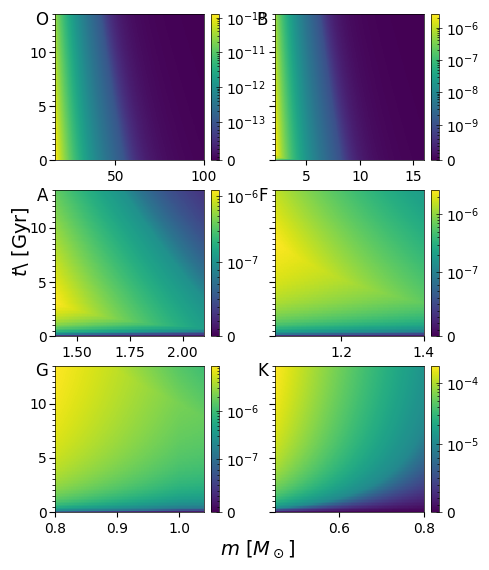

In [171]:
import graphpackage as gp
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import SymmetricalLogLocator
import importlib
gp = importlib.reload(gp)
from graphpackage import SymlogMinorLocator
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

n_cols = 2
n_types = 6
n_rows = int(np.ceil(n_types / n_cols))
fig, axes = plt.subplots(3, 2, figsize=(gp.xaxisSize, 6), sharex=False, sharey=True)
axes = axes.flatten()

def get_order(num):
    return np.floor(np.log10(np.abs(num)))

star_dict = stars_params.copy()

for idx, stype in enumerate(['O', 'B', 'A', 'F', 'G', 'K']):
    mmin_cat, mmax_cat = star_types[stype]
    vmin, vmax = 0, stars[stype]['SCH'].max()
    m_vals = star_dict[stype]['m_vals']
    contrib_matrix = star_dict[stype]['SCH_grid']
    t_array = star_dict[stype]['t_vals']
    
    factor = 0.25  # adjust this (e.g., 0.1, 0.25, 0.5) for speed vs quality
    #contrib_matrix_ds = zoom(contrib_matrix, factor)
    #t_array_ds = zoom(t_array, factor)
    #m_vals_ds = zoom(m_vals, factor)
    
    if stype in ['O', 'B']:
        linthresh = np.power(10, get_order(contrib_matrix.max())-3)
    else:
        linthresh = np.power(10, get_order(contrib_matrix.max())-1)
    norm = mpl.colors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    im = axes[idx].pcolormesh(m_vals, t_array, contrib_matrix, shading='auto', norm=norm, cmap='viridis', rasterized=True)
    
    #apply_scientific_formatter(axes[idx], axis='x')
    axes[idx].yaxis.set_minor_locator(AutoMinorLocator(10))
    # axes[idx].set_title(f"Type {stype}", fontsize=14)
    cbar = fig.colorbar(im, ax=axes[idx], pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.yaxis.set_major_locator(SymmetricalLogLocator(linthresh=linthresh,base=10))
    #cbar.ax.yaxis.set_minor_locator(CustomSymLogMinorLocator(linthresh=linthresh, base=10))
    cbar.ax.yaxis.set_minor_locator(SymlogMinorLocator(linthresh, n_lin=10, c_max=contrib_matrix.max()))
    
    #cbar.ax.yaxis.set_minor_formatter(FuncFormatter(sci_label))     
    cbar.ax.tick_params(which='minor', length=1.5, width=0.5, color='black', direction="in")
    cbar.ax.tick_params(which='major', length=4, width=0.5, color='black', direction="inout")

    for spine in axes[idx].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)

    # Set edge line for the colorbar
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
    #print(f"Celkový integrovaný příspěvek v posledním čase pro typ {stype}: {total_contrib}")
    #axes[idx].set_aspect('equal')
    axes[idx].text(-0.05, 0.9, f'{stype}',
        transform=axes[idx].transAxes,
        fontsize=12, ha='right', va='bottom')
    
    axes[idx].tick_params(axis='y', which='major',
                labelsize=10, length=4, pad=2)

# Skryjeme prázdné subploty, pokud nějaké zbydou
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)
    
fig.supxlabel(r"$m\ [M_\odot]$", fontsize=14, y=-0.03)
fig.supylabel(r"$t$\ [Gyr]", fontsize=14, x = 0.01)
fig.subplots_adjust(bottom=0.05, left=0.1)
plt.rc('text', usetex=True)
# plt.savefig("SH1_small.pdf",  bbox_inches='tight', dpi=600)
plt.show()

[ 1.     1.007  1.014 ... 99.76  99.84  99.92 ]


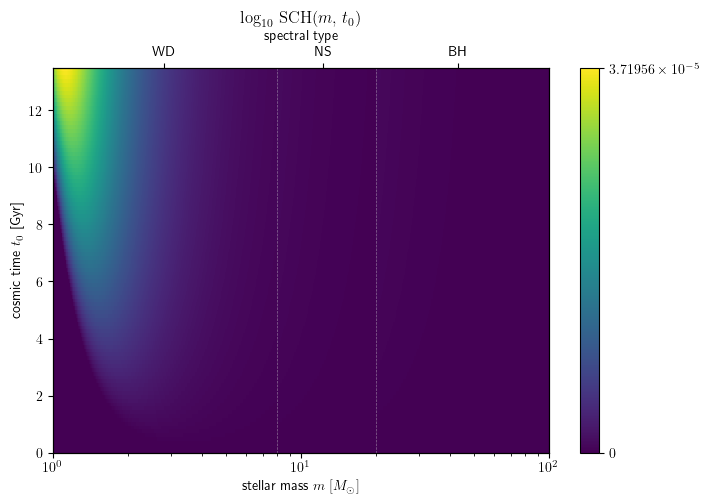

In [172]:
def minmax(n):
    return np.min(n), np.max(n)
m_edges = np.concatenate([stars[k]['m'][:-1] for k in order if k in ['BH', 'NS', 'WD']])
m_hline_edges = [stars[k]['m'][0] for k in order if k in ['BH', 'NS', 'WD']]
m_hline_edges = np.append(m_hline_edges, [100])
m_ticks_centres = [
    10**(0.5*np.log10(stars[k]['m'][0]) + 0.5*np.log10(stars[k]['m'][-1]))
    for k in order if k in ['BH', 'NS', 'WD']]

SCH = np.column_stack([stars[k]['SCH'] for k in order if k in ['BH', 'NS', 'WD']])             # shape (nt-1, 8*(nm-1)))))

fig, ax = plt.subplots(figsize=(8, 5))
extent = [min(m_edges), max(m_edges), 0.0, T_final]
import matplotlib as mpl
pcm = ax.pcolormesh(np.append(m_edges, max(m_edges)), t_vals, SCH, shading='auto', norm=mpl.colors.SymLogNorm(linthresh=1e5))
cbar = ax.figure.colorbar(pcm, ax=ax)

print(m_edges)

ax.vlines(m_hline_edges, 0, T_final, color='lightgray', linestyle='--', lw=0.5, alpha=0.5)

axt = ax.twiny()
axt.set_xscale('log')
axt.set_xticks(m_ticks_centres)
axt.set_xticklabels([key for key in order if key in ['BH', 'NS', 'WD']])
axt.set_xlabel('spectral type')
axt.set_xlim(ax.get_xlim())

log_ticks = np.log10([0.01, 0.1, 1, 10, 100])
ax.set_xticks(log_ticks)
ax.set_xticklabels([0.01, 0.1, 1, 10, 100])
ax.set_xscale('log')
ax.set_xlim(np.min(star_types['WD']), np.max(star_types['BH']))

ax.set_xlabel(r"stellar mass $m \;[M_\odot]$")
ax.set_ylabel(r"cosmic time $t_0$ [Gyr]")
ax.set_title(r"$\log_{10}\,{\rm SCH}(m,\,t_0)$")
axt.minorticks_off()

Major ticks: [-1.  0.  1.]
Minor ticks: [-9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -0.8 -0.6 -0.4 -0.2  0.   0.2
  0.4  0.6  0.8  2.   3.   4.   5.   6.   7.   8.   9. ]
Linear-zone minors (should be 8 incl. negatives): [-0.8, -0.6, -0.3999999999999999, -0.19999999999999996, 0.2, 0.4, 0.6000000000000001, 0.8]
Saved PNG to symlog_test.png – open it if GUI hides ticks.
True True


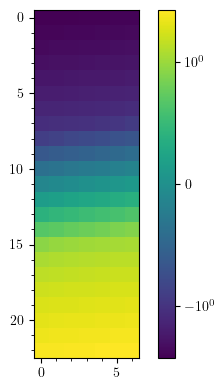

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator

# --------------------------------------------------------------------
# Parameters
linthresh = 1.0   # linear zone is −1 … +1
n_sub      = 4    # want four minor ticks in that zone
# --------------------------------------------------------------------

# Dummy image --------------------------------------------------------
z    = np.linspace(-3, 3, 161).reshape(23, 7)
norm = mcolors.SymLogNorm(linthresh, vmin=-3, vmax=3, base=10)

fig, ax = plt.subplots(figsize=(4, 4))
im   = ax.imshow(z, norm=norm, cmap='viridis')
cbar = fig.colorbar(im, ax=ax)

# Major ticks --------------------------------------------------------
major_locator = mticker.SymmetricalLogLocator(linthresh=linthresh, base=10)
major_ticks   = major_locator.tick_values(cbar.norm.vmin, cbar.norm.vmax)
cbar.set_ticks(major_ticks)

# Minor ticks: build list -------------------------------------------
log_minor = mticker.SymmetricalLogLocator(
                linthresh=linthresh, base=10, subs=range(2, 10)
            ).tick_values(cbar.norm.vmin, cbar.norm.vmax)

linear_minor = []
for lo, hi in zip(major_ticks[:-1], major_ticks[1:]):
    if abs((lo + hi) * 0.5) < linthresh:         # segment is linear
        step = (hi - lo) / (n_sub + 1)
        linear_minor.extend(lo + k*step for k in range(1, n_sub + 1))

minor_ticks = np.unique(np.concatenate([log_minor, linear_minor]))
cbar.ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
cbar.minorticks_on()

# Highlight the four linear minors (make them long & red) ------------
for line in cbar.ax.yaxis.get_minorticklines():
    ydata = line.get_ydata()[0]
    if abs(ydata) < linthresh:          # inside linear zone – our 4 ticks
        line.set_color('red')
        line.set_linewidth(1.5)
        line.set_markersize(0)
        line.set_alpha(1)
        line.set_length = 20            # draw VERY long
        line.set_linestyle('-')
        line.set_marker(None)
        line.set_clip_on(False)
        line.set_zorder(10)
        line.set_transform(cbar.ax.transData)
        line.set_path_effects([])       # no fancy effects
cbar.ax.tick_params(which='minor', length=20, color='red')  # back-stop

# --- diagnostics ----------------------------------------------------
print("Major ticks:", major_ticks)
print("Minor ticks:", minor_ticks)
print("Linear-zone minors (should be 8 incl. negatives):",
      [v for v in minor_ticks if abs(v) < linthresh and v != 0])

# save file for out-of-GUI inspection
fig.savefig('symlog_test.png', dpi=150)
print("Saved PNG to symlog_test.png – open it if GUI hides ticks.")
# --------------------------------------------------------------------

print(mpl.rcParams['xtick.minor.visible'],
      mpl.rcParams['ytick.minor.visible'])


plt.tight_layout()import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator
import matplotlib as mpl

# --------------------------------------------------------------------
# ensure minor ticks are allowed to be drawn
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
# --------------------------------------------------------------------

linthresh = 1.0   # linear zone −1…+1
n_sub      = 4    # four minor ticks in that zone

# --------------------------------------------------------------------
#  helper: compute minor ticks for a symlog axis
# --------------------------------------------------------------------
def compute_symlog_minors(linthresh, vmin, vmax, majors, n_sub=4):
    log_minor = mticker.SymmetricalLogLocator(
        linthresh=linthresh, base=10, subs=range(2, 10)
    ).tick_values(vmin, vmax)

    linear_minor = []
    for lo, hi in zip(majors[:-1], majors[1:]):
        if abs((lo + hi) * 0.5) < linthresh:
            step = (hi - lo) / (n_sub + 1)
            linear_minor.extend(lo + k * step for k in range(1, n_sub + 1))

    return np.unique(np.concatenate([log_minor, linear_minor]))

# --------------------------------------------------------------------
#  build the figure
# --------------------------------------------------------------------
data = np.linspace(-3, 3, 161).reshape(23, 7)
norm = mcolors.SymLogNorm(linthresh, vmin=-3, vmax=3, base=10)

fig, ax = plt.subplots(figsize=(4, 4))
im   = ax.imshow(data, norm=norm, cmap='viridis')
cbar = fig.colorbar(im, ax=ax)

# major ticks
majloc       = mticker.SymmetricalLogLocator(linthresh=linthresh, base=10)
major_ticks  = majloc.tick_values(cbar.norm.vmin, cbar.norm.vmax)
cbar.set_ticks(major_ticks)

# minor ticks
minor_ticks  = compute_symlog_minors(
    linthresh, cbar.norm.vmin, cbar.norm.vmax, major_ticks, n_sub
)
cbar.ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
cbar.minorticks_on()
cbar.ax.tick_params(which='minor', length=6, color='red')  # red & long

plt.tight_layout()
plt.show()

plt.show()


In [229]:
import numpy as np
import matplotlib.ticker as mticker
from matplotlib.ticker import Locator


class MinorSymLogLocator(Locator):
    """
    Minor-tick locator for symmetric-log axes (or colour-bars).

    Parameters
    ----------
    linthresh : float
        Width of the linear region (±``linthresh``).
    n_sub : int, default 4
        *Exact* number of minor ticks to draw **between each pair of
        adjacent major ticks that lie inside the linear region**.
    base : float, default 10
        Logarithmic base used outside the linear region.
    subs : sequence of int, default range(2, 10)
        Decade subdivisions (2…9 ⇒ the usual log-minor ticks).
    """

    def __init__(self, linthresh, n_sub=4, base=10, subs=range(2, 10)):
        self.linthresh = float(linthresh)
        self.n_sub = int(n_sub)

        # Locator that supplies the usual log-minor ticks.
        self._logminor = mticker.SymmetricalLogLocator(
            linthresh=self.linthresh,
            base=base,
            subs=list(subs)           # make sure we have an indexable list
        )

    # ------------------------------------------------------------------
    def _linear_minor(self, majors):
        """Return the `n_sub` evenly spaced ticks inside ±linthresh."""
        minors = []
        for lo, hi in zip(majors[:-1], majors[1:]):
            if abs((lo + hi) * 0.5) < self.linthresh:          # gap is linear
                step = (hi - lo) / (self.n_sub + 1)
                minors.extend(lo + k * step for k in range(1, self.n_sub + 1))
        return minors

    # ------------------------------------------------------------------
    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        majors = self.axis.get_majorticklocs()

        # 1) log-minor ticks outside the linear region
        minors_log = self._logminor.tick_values(vmin, vmax)
        # 2) linear-minor ticks inside the linear region
        minors_lin = self._linear_minor(majors)

        # merge, deduplicate, sort
        ticks = np.unique(np.concatenate([minors_log, minors_lin]))
        return self.raise_if_exceeds(ticks)

    # ------------------------------------------------------------------
    def tick_values(self, vmin, vmax):
        """
        Required by the `Locator` base class for some internal calls.
        Builds a temporary dummy axis so that ``__call__`` can run.
        """
        dummy_axis = type(
            "DummyAxis",
            (),
            {
                "get_view_interval":   lambda *a: (vmin, vmax),
                "get_majorticklocs":   lambda *a: np.array(
                    [-self.linthresh, 0.0, self.linthresh])
            }
        )
        self.axis = dummy_axis()
        ticks = self()
        return ticks[(ticks >= vmin) & (ticks <= vmax)]


Figure written to symlog_demo.png


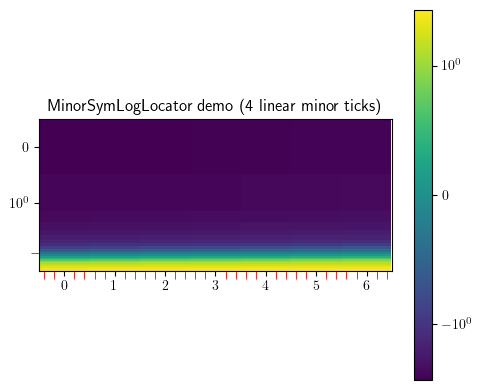

In [230]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Demonstration of MinorSymLogLocator (4 linear minor ticks) on
both a symlog axis and a symlog colour-bar.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.ticker import Locator, FixedLocator
import matplotlib as mpl

# ------------------------------------------------------------
# Make absolutely sure minor ticks are allowed to be drawn
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
# ------------------------------------------------------------


# ------------------------------------------------------------
# MinorSymLogLocator definition
# ------------------------------------------------------------
class MinorSymLogLocator(Locator):
    """
    Minor ticks for a symlog axis (or colour-bar).

    • Inside |x| < linthresh: exactly `n_sub` evenly-spaced ticks
      between each pair of adjacent major ticks.
    • Outside that region: usual decade subdivisions (2…9).
    """
    def __init__(self, linthresh, n_sub=4, base=10, subs=range(2, 10)):
        self.linthresh = float(linthresh)
        self.n_sub     = int(n_sub)
        self._logminor = mticker.SymmetricalLogLocator(
            linthresh=self.linthresh, base=base, subs=list(subs)
        )

    # ----- helpers ----------------------------------------------------
    def _linear_minor(self, majors):
        out = []
        for lo, hi in zip(majors[:-1], majors[1:]):
            if abs((lo + hi) * 0.5) < self.linthresh:      # in linear zone
                step = (hi - lo) / (self.n_sub + 1)
                out.extend(lo + k * step for k in range(1, self.n_sub + 1))
        return out

    # ----- API --------------------------------------------------------
    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        majors     = self.axis.get_majorticklocs()
        minors_log = self._logminor.tick_values(vmin, vmax)
        minors_lin = self._linear_minor(majors)
        ticks = np.unique(np.concatenate([minors_log, minors_lin]))
        return self.raise_if_exceeds(ticks)

    def tick_values(self, vmin, vmax):
        # fallback for autoscale
        self.axis = type(
            "DummyAxis",
            (),
            {"get_view_interval": lambda *a: (vmin, vmax),
             "get_majorticklocs": lambda *a: np.array(
                 [-self.linthresh, 0.0, self.linthresh])}
        )()
        ticks = self()
        return ticks[(ticks >= vmin) & (ticks <= vmax)]


# ------------------------------------------------------------
# Demo parameters
linthresh = 1.0       # ±1 is linear region
n_sub      = 4        # want four minor ticks there
# ------------------------------------------------------------

# Dummy data for an image -----------------------------------
data = np.linspace(-3, 3, 161).reshape(23, 7)
norm = mcolors.SymLogNorm(linthresh, vmin=-3, vmax=3, base=10)

fig, ax = plt.subplots(figsize=(5, 4))
im  = ax.imshow(data, norm=norm, cmap='viridis')
cbar = fig.colorbar(im, ax=ax)

# ----- major ticks (axis & colour-bar) ----------------------
majloc = mticker.SymmetricalLogLocator(linthresh=linthresh, base=10)
ax.set_yscale('symlog', linthresh=linthresh, base=10)
ax.yaxis.set_major_locator(majloc)
cbar.ax.yaxis.set_major_locator(majloc)

# ----- minor ticks with our locator -------------------------
minor_loc = MinorSymLogLocator(linthresh, n_sub)
ax.yaxis.set_minor_locator(minor_loc)

# For the colour-bar use a FixedLocator so update_ticks() can’t overwrite it
minor_ticks = minor_loc.tick_values(cbar.norm.vmin, cbar.norm.vmax)
cbar.ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))

# Make them visible & red for clarity ------------------------
ax.minorticks_on()
cbar.minorticks_on()
ax.tick_params(which='minor', length=6, color='red')
cbar.ax.tick_params(which='minor', length=6, color='red')

ax.set_title("MinorSymLogLocator demo (4 linear minor ticks)")
fig.tight_layout()
fig.savefig("symlog_demo.png", dpi=150)
print("Figure written to symlog_demo.png")
plt.show()


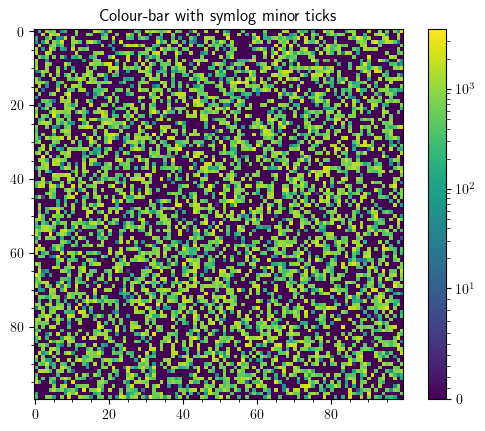

In [ ]:
import numpy as np
import matplotlib.ticker as mticker

class SymlogMinorLocator(mticker.Locator):
    """
    Minor-tick locator for a positive-only symlog colour-bar.

    Parameters
    ----------
    linthresh : float
        Width of the linear region (0 → linthresh).
    n_lin : int, default 4
        How many *minor* ticks inside the linear part (0 excluded).
    subs : sequence or None, default None
        Log subdivisions in the log part (> linthresh).  
        *None* ⇒ all subs 2…(base-1).
    base : float, default 10.0
        Logarithmic base.
    c_max : float or None
        Upper limit for the colour-bar.  If *None*, uses the axis view limit.
    """
    def __init__(self, linthresh, n_lin=4, subs=None, base=10.0, c_max=None):
        self.linthresh = float(linthresh)
        self.n_lin = int(max(0, n_lin))
        self.base = float(base)
        self.c_max = c_max
        if subs is None:
            self.subs = np.arange(2, self.base)          # 2…9 → “all”
        else:
            self.subs = np.asarray(subs, dtype=float)

    # --- mandatory API --------------------------------------------------
    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        return self.tick_values(vmin, vmax)

    def tick_values(self, vmin, vmax):
        vmax = self.c_max if self.c_max is not None else vmax
        vmax = max(vmax, self.linthresh)
        # 1. linear part (0 → linthresh)
        lin_ticks = (
            np.linspace(0, self.linthresh, self.n_lin + 1, endpoint=True)[1:]
            if self.n_lin > 0 else np.array([])
        )

        # 2. logarithmic part (> linthresh)
        log_locator = mticker.LogLocator(base=self.base,
                                         subs=self.subs,
                                         numticks=100)
        log_ticks = log_locator.tick_values(self.linthresh, vmax)
        log_ticks = log_ticks[log_ticks > self.linthresh]    # discard overlap

        ticks = np.concatenate((lin_ticks, log_ticks))
        return self.raise_if_exceeds(ticks)


import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# Synthetic data
data = np.random.randn(100, 100) * 1e3
linthresh = 10
cmax = np.abs(data).max()

fig, ax = plt.subplots()
im = ax.imshow(data, norm=SymLogNorm(linthresh=linthresh, vmin=0, vmax=cmax))

cb = fig.colorbar(im, ax=ax)
cb.ax.yaxis.set_minor_locator(SymlogMinorLocator(linthresh, n_lin=10, c_max=cmax))

cb.ax.tick_params(which='minor', width=0.5, length=3)
ax.set_title("Colour-bar with symlog minor ticks")
plt.show()


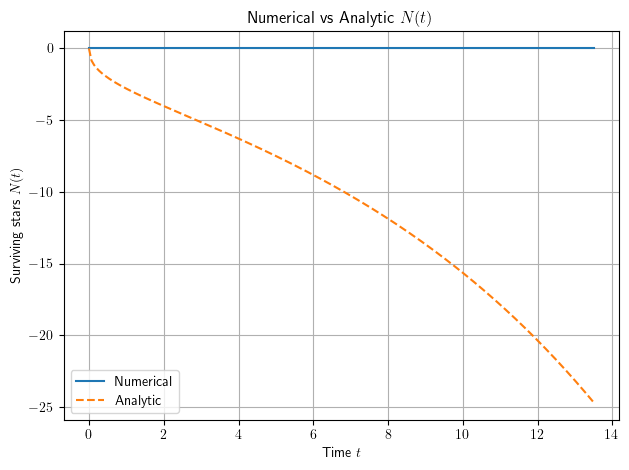

In [232]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, gammainc

# Parameters
T = 8.4
alpha = 2.3
delta = 3.5
m_min = 16
m_max = 100
tau_max = 13.5

# Numerical integration setup (reuse previous integrand approach)
ms = np.linspace(m_min, m_max, 2000)
ts = np.linspace(0, tau_max, 200)
# Precompute mass integrand numeric
def compute_N_numeric(t):
    if t == 0:
        return 0.0
    m_cut = (10.0 / t)**(1.0 / delta)
    A1 = T * (np.exp(t / T) - 1)
    A2 = T * np.exp(t / T)
    integrand = np.where(
        ms < m_cut,
        A1 * ms**(-alpha),
        A2 * ms**(-alpha) * (1 - np.exp(-10.0 * ms**(-delta) / T))
    )
    return np.trapz(integrand, ms)

N_num = np.array([compute_N_numeric(t) for t in ts])

# Analytical N(t) using incomplete gamma functions
def N_analytic(t):
    if t == 0:
        return 0.0
    m_cut = (10.0 / t)**(1.0 / delta)
    # N1
    if m_cut <= m_min:
        N1 = 0.0
    elif m_cut >= m_max:
        N1 = T * (np.exp(t / T) - 1) * (m_max**(1-alpha) - m_min**(1-alpha)) / (1-alpha)
    else:
        N1 = T * (np.exp(t / T) - 1) * (m_cut**(1-alpha) - m_min**(1-alpha)) / (1-alpha)
    # N2
    lower = max(m_cut, m_min)
    I1 = (m_max**(1-alpha) - lower**(1-alpha)) / (1-alpha)
    s = (alpha-1) / delta
    x1 = t / T
    x2 = (10.0 / T) * (m_max**(-delta))
    I2 = (1.0 / delta) * (T / 10.0)**s * (gamma(s) * gammainc(s, x1) - gamma(s) * gammainc(s, x2))
    N2 = T * np.exp(t / T) * (I1 - I2)
    return N1 + N2

N_analytic_vals = np.array([N_analytic(t) for t in ts])

# Plot numeric and analytic
plt.figure()
plt.plot(ts, N_num, label='Numerical')
plt.plot(ts, N_analytic_vals, linestyle='--', label='Analytic')
plt.xlabel('Time $t$')
plt.ylabel('Surviving stars $N(t)$')
plt.title('Numerical vs Analytic $N(t)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [289]:
import sympy as sp
from sympy import Piecewise, integrate, exp, gamma
from sympy import init_printing
from IPython.display import display

# Initialize MathJax printing
init_printing(use_latex='mathjax')

# Define symbols
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m', positive=True, real=True
)

# Critical mass
m_c = (a/t)**(1/δ)

# Integrals with special functions
I_all = integrate(m**(-α), (m, mMin, mMax))
I_partial = integrate(
    m**(-α)*(1 - exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax),
    conds='none',
    meijerg=True
)
I_full = integrate(
    m**(-α)*(τ*(1 - exp(-t/τ)) - τ*(1 - exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax),
    conds='none',
    meijerg=True
)

# Branch expressions
expr_partial = 1/(τ*(1 - exp(-T0/τ))) * (τ*(1 - exp(-t/τ))*I_all - τ*I_partial)
expr_full    = 1/(τ*(1 - exp(-T0/τ))) * I_full

# Piecewise result
res_special = Piecewise(
    (expr_partial, (t > a*mMax**(-δ)) & (t < a*mMin**(-δ))),
    (expr_full,           t >= a*mMin**(-δ))
)

# Simplify and display with MathJax
res_simp = sp.simplify(res_special)
display(res_simp)


⎧⎧ ⎛                                           ⎛                          mMax ↪
⎪⎪ ⎜                                           ⎜                           ⌠   ↪
⎪⎪ ⎜                                           ⎜                           ⎮   ↪
⎪⎪ ⎜                        ⎛ t    ⎞           ⎜ t    mMax                 ⎮   ↪
⎪⎪ ⎜                        ⎜ ─    ⎟           ⎜ ─     ⌠                   ⎮   ↪
⎪⎪ ⎜⎛    1 - α       1 - α⎞ ⎜ τ    ⎟           ⎜ τ     ⎮       -α          ⎮   ↪
⎪⎪-⎜⎝mMax      - mMin     ⎠⋅⎝ℯ  - 1⎠ + (α - 1)⋅⎜ℯ ⋅    ⎮      m   dm -     ⎮   ↪
⎪⎪ ⎜                                           ⎜       ⌡                   ⌡   ↪
⎪⎪ ⎜                                           ⎜          -1                   ↪
⎪⎪ ⎜                                           ⎜          ───                  ↪
⎪⎪ ⎜                                           ⎜   δ ___   δ           δ ___   ↪
⎪⎪ ⎝                                           ⎝   ╲╱ a ⋅t             ╲╱ a ⋅t ↪
⎪⎪──────────────────────────

In [290]:
import sympy as sp
from sympy import Piecewise, integrate, exp, init_printing
from IPython.display import display

# Initialize MathJax printing
init_printing(use_latex='mathjax')

# Define symbols
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m', positive=True, real=True
)

# Critical mass
m_c = (a/t)**(1/δ)

# Compute integrals with special functions forced
I_all = integrate(m**(-α), (m, mMin, mMax), conds='none')
I_partial = integrate(
    m**(-α)*(1 - exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax),
    conds='none',
    meijerg=True
)
I_full = integrate(
    m**(-α)*(τ*(1 - exp(-t/τ)) - τ*(1 - exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax),
    conds='none',
    meijerg=True
)

# Branch expressions
expr_partial = 1/(τ*(1 - exp(-T0/τ))) * (τ*(1 - exp(-t/τ))*I_all - τ*I_partial)
expr_full    = 1/(τ*(1 - exp(-T0/τ))) * I_full

# Assemble and simplify piecewise
res_special = Piecewise(
    (expr_partial, (t > a*mMax**(-δ)) & (t < a*mMin**(-δ))),
    (expr_full,           t >= a*mMin**(-δ))
)
res_simp = sp.simplify(res_special)

# Display the fully computed piecewise result
display(res_simp)


⎧ ⎛                                           ⎛                          mMax  ↪
⎪ ⎜                                           ⎜                           ⌠    ↪
⎪ ⎜                                           ⎜                           ⎮    ↪
⎪ ⎜                        ⎛ t    ⎞           ⎜ t    mMax                 ⎮    ↪
⎪ ⎜                        ⎜ ─    ⎟           ⎜ ─     ⌠                   ⎮    ↪
⎪ ⎜⎛    1 - α       1 - α⎞ ⎜ τ    ⎟           ⎜ τ     ⎮       -α          ⎮    ↪
⎪-⎜⎝mMax      - mMin     ⎠⋅⎝ℯ  - 1⎠ + (α - 1)⋅⎜ℯ ⋅    ⎮      m   dm -     ⎮    ↪
⎪ ⎜                                           ⎜       ⌡                   ⌡    ↪
⎪ ⎜                                           ⎜          -1                  - ↪
⎪ ⎜                                           ⎜          ───                 ─ ↪
⎪ ⎜                                           ⎜   δ ___   δ           δ ___    ↪
⎪ ⎝                                           ⎝   ╲╱ a ⋅t             ╲╱ a ⋅t  ↪
⎪───────────────────────────

In [298]:
import sympy as sp

# Initialize LaTeX printing for MathJax
sp.init_printing(use_latex='mathjax')

# Define symbols
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m', positive=True, real=True
)

# Critical mass
m_c = (a/t)**(1/δ)

# Compute integrals with special functions forced
I_all = sp.integrate(m**(-α), (m, mMin, mMax), conds='none', meijerg=True)
I_partial = sp.integrate(
    m**(-α)*(1 - sp.exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax),
    conds='none',
    meijerg=True
)
I_full = sp.integrate(
    m**(-α)*(τ*(1 - sp.exp(-t/τ)) - τ*(1 - sp.exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax),
    conds='none',
    meijerg=True
)

# Branch expressions
expr_partial = 1/(τ*(1 - sp.exp(-T0/τ))) * (τ*(1 - sp.exp(-t/τ))*I_all - τ*I_partial)
expr_full    = 1/(τ*(1 - sp.exp(-T0/τ))) * I_full

# Assemble piecewise
res_special = sp.Piecewise(
    (expr_partial, (t > a*mMax**(-δ)) & (t < a*mMin**(-δ))),
    (expr_full,           t >= a*mMin**(-δ))
)

import mpmath as mp

mp_map = {
    'gamma':     mp.gamma,            # Gamma(s)
    'uppergamma': lambda s, x: mp.gammainc(s, x),  # Upper incomplete gamma Γ(s, x)
    'meijerg':   mp.meijerg           # Meijer G
}

res_mp = sp.lambdify(
    (t, α, δ, τ, T0, mMin, mMax, a),
    res_special,
    modules=[mp_map]
)

# 5) Vectorize for NumPy arrays
def res_np(t_array, alpha, delta, tau, T0_val, mMin_val, mMax_val, a_val):
    """
    Vectorized evaluation of res_special using mpmath for Meijer G.
    """
    f = lambda ti: res_mp(ti, alpha, delta, tau, T0_val, mMin_val, mMax_val, a_val)
    return np.vectorize(f, otypes=[float])(t_array)


PrintMethodNotImplementedError: Unsupported by <class 'sympy.printing.pycode.PythonCodePrinter'>: <class 'sympy.integrals.integrals.Integral'>
Set the printer option 'strict' to False in order to generate partially printed code.

In [299]:
import numpy as np
import sympy as sp
import mpmath as mp
import matplotlib.pyplot as plt

# 1) Define symbols (must match those in your Sympy expression)
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m', positive=True, real=True
)

# 2) Critical mass
m_c = (a/t)**(1/δ)

# 3) Compute integrals with Meijer G
I_all = sp.integrate(m**(-α), (m, mMin, mMax), conds='none', meijerg=True)
I_partial = sp.integrate(
    m**(-α)*(1 - sp.exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax),
    conds='none',
    meijerg=True
)
I_full = sp.integrate(
    m**(-α)*(τ*(1 - sp.exp(-t/τ)) - τ*(1 - sp.exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax),
    conds='none',
    meijerg=True
)

# 4) Piecewise expression
expr_partial = 1/(τ*(1 - sp.exp(-T0/τ))) * (τ*(1 - sp.exp(-t/τ))*I_all - τ*I_partial)
expr_full    = 1/(τ*(1 - sp.exp(-T0/τ))) * I_full

res_special = sp.Piecewise(
    (expr_partial, (t > a*mMax**(-δ)) & (t < a*mMin**(-δ))),
    (expr_full,           t >= a*mMin**(-δ))
)

# 5) Map Sympy special functions to mpmath
mp_map = {
    'gamma':     mp.gamma,             # Gamma(s)
    'uppergamma': lambda s, x: mp.gammainc(s, x),  # Upper incomplete gamma Γ(s, x)
    'meijerg':   mp.meijerg            # Meijer G
}

# 6) Lambdify to get an mpmath-backed scalar function
res_mp = sp.lambdify(
    (t, α, δ, τ, T0, mMin, mMax, a),
    res_special,
    modules=[mp_map]
)

# 7) Vectorized wrapper for NumPy arrays
def res_np(t_array, alpha, delta, tau, T0_val, mMin_val, mMax_val, a_val):
    f_scalar = lambda ti: res_mp(ti, alpha, delta, tau, T0_val, mMin_val, mMax_val, a_val)
    return np.vectorize(f_scalar, otypes=[float])(t_array)

# 8) Example usage & plot
alpha_val, delta_val = 2.5, 0.5
tau_val, T0_val     = 2.0, 10.0
mMin_val, mMax_val  = 0.1, 1.0
a_val               = 0.5

t_vals = np.linspace(0.1, T0_val, 300)
res_vals = res_np(t_vals, alpha_val, delta_val, tau_val, T0_val, mMin_val, mMax_val, a_val)

plt.plot(t_vals, res_vals, lw=2)
plt.xlabel('t')
plt.ylabel('res(t)')
plt.title('res(t) using Meijer G (mpmath)')
plt.grid(True)
plt.tight_layout()
plt.show()


PrintMethodNotImplementedError: Unsupported by <class 'sympy.printing.pycode.PythonCodePrinter'>: <class 'sympy.integrals.integrals.Integral'>
Set the printer option 'strict' to False in order to generate partially printed code.

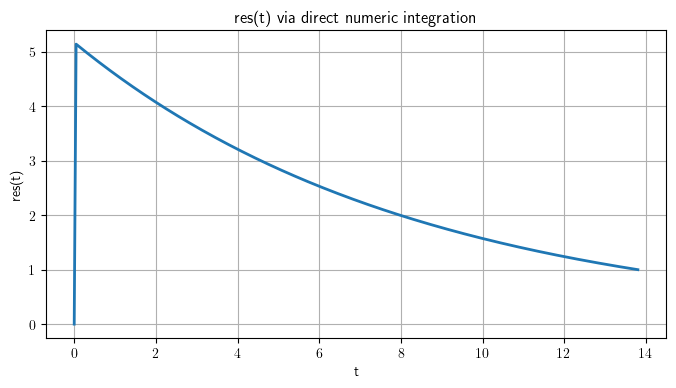

In [307]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt

# ——— Example parameters ———
α, δ = 2.3, 2.5
τ, T0 = 8.4, 13.8
mMin, mMax = 16, 100
a = 10

# normalization
den = τ*(1 - np.exp(-T0/τ))

# original integrand with Heaviside
def integrand(m, t):
    F1 = (τ - τ*mp.e**(-t/τ)) / den
    F2 = (τ - τ*mp.e**(-(t - a*m**(-δ))/τ)) / den
    H  = 1 if t >= a*m**(-δ) else 0
    return m**(-α)*(F1 - F2*H)

# piecewise integral
def res_scalar(t):
    if t < 0:
        return 0.0
    return mp.quad(lambda mm: integrand(mm, t), [mMin, mMax])

# vectorize over numpy
res = np.vectorize(lambda tt: float(res_scalar(tt)))

# sample & plot
t_vals = np.linspace(0, T0, 300)
res_vals = res(t_vals)
res_vals = res_vals / res_vals[-1]  # normalize

plt.figure(figsize=(8,4))
plt.plot(t_vals, res_vals, lw=2)
plt.xlabel('t')
plt.ylabel('res(t)')
plt.title('res(t) via direct numeric integration')
plt.grid(True)
plt.show()


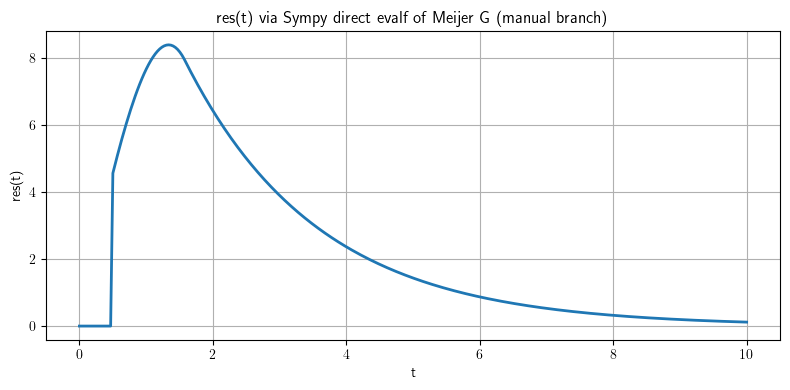

In [310]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 1) Define symbols exactly as in your symbolic solution
t, alpha, delta, tau, T0, mMin, mMax, a, m = sp.symbols(
    't alpha delta tau T0 mMin mMax a m', positive=True, real=True
)

# 2) Reconstruct the symbolic 'res_special' (your two-branch Meijer G solution)
m_c = (a/t)**(1/delta)
I_all = sp.integrate(m**(-alpha), (m, mMin, mMax), meijerg=True).doit()
I_partial = sp.simplify(sp.integrate(
    m**(-alpha)*(1 - sp.exp(-(t - a*m**(-delta))/tau)),
    (m, m_c, mMax),
    meijerg=True
).doit())
I_full = sp.simplify(sp.integrate(
    m**(-alpha)*(tau*(1 - sp.exp(-t/tau)) - tau*(1 - sp.exp(-(t - a*m**(-delta))/tau))),
    (m, mMin, mMax),
    meijerg=True
).doit())

expr_partial = (1/(tau*(1 - sp.exp(-T0/tau))) *
                (tau*(1 - sp.exp(-t/tau))*I_all - tau*I_partial))
expr_full = 1/(tau*(1 - sp.exp(-T0/tau))) * I_full

# 3) Numeric wrapper: manually pick branch and eval
def res_np_sym(t_array, alpha_val, delta_val, tau_val, T0_val, mMin_val, mMax_val, a_val):
    # thresholds
    t1 = a_val * mMax_val**(-delta_val)
    t2 = a_val * mMin_val**(-delta_val)
    # substitution dict for parameters
    subs_dict = {
        alpha: alpha_val, delta: delta_val, tau: tau_val,
        T0: T0_val, mMin: mMin_val, mMax: mMax_val, a: a_val
    }
    results = []
    for ti in t_array:
        if ti < t1:
            results.append(0.0)
        elif ti < t2:
            val = expr_partial.subs({**subs_dict, t: ti}).evalf(chop=True)
            # extract real part
            results.append(float(sp.re(val)))
        else:
            val = expr_full.subs({**subs_dict, t: ti}).evalf(chop=True)
            results.append(float(sp.re(val)))
    return np.array(results)

# 4) Example usage and plot
params = (2.5, 0.5, 2.0, 10.0, 0.1, 1.0, 0.5)
t_vals = np.linspace(0, params[3], 300)
res_vals = res_np_sym(t_vals, *params)

plt.figure(figsize=(8,4))
plt.plot(t_vals, res_vals, lw=2)
plt.xlabel('t')
plt.ylabel('res(t)')
plt.title('res(t) via Sympy direct evalf of Meijer G (manual branch)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [319]:
import sympy as sp

# 1) Declare your symbols.
t, alpha, delta, tau, T0, mMin, mMax, a = sp.symbols(
    't alpha delta tau T0 mMin mMax a',
    positive=True, real=True
)
m = sp.symbols('m', positive=True, real=True)

# 2) Define the critical mass m_c and the normalization.
m_c = (a/t)**(1/delta)
norm = tau*(1 - sp.exp(-T0/tau))

# 3) Compute the power‐law integral in closed form.
I_all = sp.integrate(m**(-alpha), (m, mMin, mMax))
#   → (mMax**(1-alpha) - mMin**(1-alpha))/(1-alpha)

# 4) Compute the “partial‐flip” branch:
#    ∫_{m_c}^{mMax} m^{-α} (1 - exp(-(t - a m^{-δ})/τ)) dm
I_partial = sp.integrate(
    m**(-alpha)*(1 - sp.exp(-(t - a*m**(-delta))/tau)),
    (m, m_c, mMax),
    conds='none',       # drop conditional piecewise on parameters
    meijerg=True        # force Meijer-G form
).doit().simplify()

# 5) Compute the “full‐flip” branch:
#    ∫_{mMin}^{mMax} m^{-α} [τ(1 - e^{-t/τ}) - τ(1 - e^{-(t - a m^{-δ})/τ})] dm
I_full = sp.integrate(
    m**(-alpha)*(tau*(1 - sp.exp(-t/tau))
                 - tau*(1 - sp.exp(-(t - a*m**(-delta))/tau))),
    (m, mMin, mMax),
    conds='none',
    meijerg=True
).doit().simplify()

# 6) Build the two branch expressions:
expr_partial = (1/norm) * (tau*(1 - sp.exp(-t/tau))*I_all - tau*I_partial)
expr_full    = (1/norm) * I_full

# 7) Print them out nicely:
display(sp.simplify(expr_full))


⎧  -α   -1               ⎛         α               ⅈ⋅π                         ↪
⎪  ───  ───            α ⎜         ─               ───  ⎛             -δ  ⅈ⋅π⎞ ↪
⎪   δ    δ  ⎛    1    ⎞  ⎜δ ___    δ            α   δ   ⎜α - 1  a⋅mMax  ⋅ℯ   ⎟ ↪
⎪-a   ⋅τ   ⋅⎜─────────⎟ ⋅⎜╲╱ a ⋅α⋅τ ⋅(mMax⋅mMin) ⋅ℯ   ⋅γ⎜─────, ─────────────⎟ ↪
⎪           ⎝mMax⋅mMin⎠  ⎝                              ⎝  δ          τ      ⎠ ↪
⎪───────────────────────────────────────────────────────────────────────────── ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎨                                                                              ↪
⎪                           

⎧                                                                              ↪
⎪                                                                              ↪
⎪  -α        1              ⎛       α + δ                                      ↪
⎪  ───  -1 - ─            α ⎜       ─────              ⎛   ⎛             -δ  ⅈ ↪
⎪   δ        δ ⎛    1    ⎞  ⎜δ ___    δ              α ⎜   ⎜α - 1  a⋅mMax  ⋅ℯ  ↪
⎪-a   ⋅τ      ⋅⎜─────────⎟ ⋅⎜╲╱ a ⋅τ     ⋅(mMax⋅mMin) ⋅⎜α⋅γ⎜─────, ─────────── ↪
⎪              ⎝mMax⋅mMin⎠  ⎝                          ⎝   ⎝  δ          τ     ↪
⎪───────────────────────────────────────────────────────────────────────────── ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎨                           

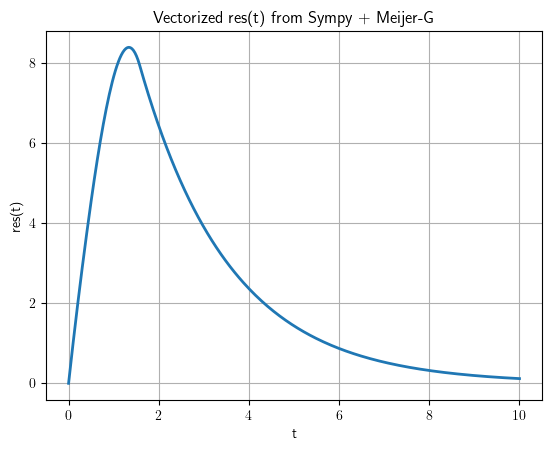

In [324]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 1) Declare symbols
t, alpha, delta, tau, T0, mMin, mMax, a, m = sp.symbols(
    't alpha delta tau T0 mMin mMax a m',
    positive=True, real=True
)

# 2) Critical mass & normalization
m_c = (a/t)**(1/delta)
norm = tau*(1 - sp.exp(-T0/tau))

# 3) Manually set the power‐law integral for α≠1
I_all = (mMax**(1-alpha) - mMin**(1-alpha)) / (1-alpha)

# 4) Compute the two Meijer‐G branches
I_partial = (
    sp.integrate(
        m**(-alpha)*(1 - sp.exp(-(t - a*m**(-delta))/tau)),
        (m, m_c, mMax),
        conds='none', meijerg=True
    )
    .doit().simplify()
)

I_full = (
    sp.integrate(
        m**(-alpha)*(tau*(1 - sp.exp(-t/tau))
                     - tau*(1 - sp.exp(-(t - a*m**(-delta))/tau))),
        (m, mMin, mMax),
        conds='none', meijerg=True
    )
    .doit().simplify()
)

# 5) Build the three branch‐expressions
expr_noflip  = (1 - sp.exp(-t/tau))*I_all / (1 - sp.exp(-T0/tau))
expr_partial = (1/norm)*(tau*(1 - sp.exp(-t/tau))*I_all - tau*I_partial)
expr_full    = (1/norm)*I_full

display(sp.simplify(sp.expand(expr_full)))

# 6) Numeric‐vectorized wrapper
def res_scalar(tt, alpha_v, delta_v, tau_v, T0_v, mMin_v, mMax_v, a_v):
    # numeric thresholds
    t1 = a_v * mMax_v**(-delta_v)
    t2 = a_v * mMin_v**(-delta_v)
    # substitution dictionary
    subs = {
        alpha: alpha_v, delta: delta_v, tau: tau_v,
        T0: T0_v, mMin: mMin_v, mMax: mMax_v, a: a_v
    }
    # pick branch
    if tt < t1:
        expr = expr_noflip
    elif tt < t2:
        expr = expr_partial
    else:
        expr = expr_full
    # substitute & evaluate to float
    val = expr.subs({**subs, t: tt}).evalf(chop=True)
    return float(sp.re(val))

# vectorize over NumPy arrays
res = np.vectorize(res_scalar, otypes=[float])

# 7) Example usage & plot
params = (2.5, 0.5, 2.0, 10.0, 0.1, 1.0, 0.5)
t_vals = np.linspace(0, params[3], 300)
res_vals = res(t_vals, *params)

plt.plot(t_vals, res_vals, lw=2)
plt.xlabel('t')
plt.ylabel('res(t)')
plt.title('Vectorized res(t) from Sympy + Meijer-G')
plt.grid(True)
plt.show()


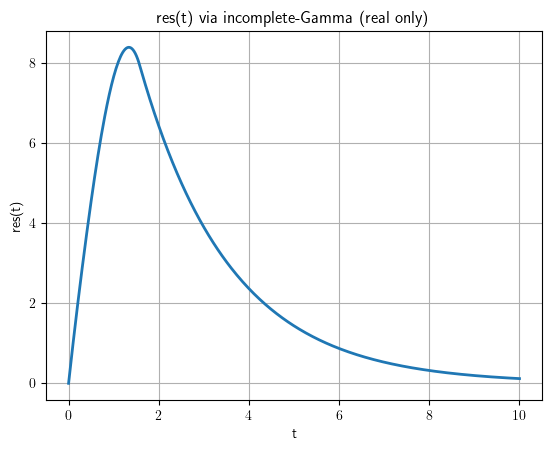

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 1) Declare symbols
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m', positive=True, real=True
)

# 2) Precompute the closed‐form integrals (no α=1 special case)
m_c       = (a/t)**(1/δ)
norm      = τ*(1 - sp.exp(-T0/τ))
I_all     = (mMax**(1-α) - mMin**(1-α)) / (1-α)
I_partial = sp.integrate(
    m**(-α)*(1 - sp.exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax), conds='none'
).doit().simplify()
I_full    = sp.integrate(
    m**(-α)*(τ*(1 - sp.exp(-t/τ)) - τ*(1 - sp.exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax), conds='none'
).doit().simplify()

# 3) Branches
expr_noflip  = (1 - sp.exp(-t/τ))*I_all / (1 - sp.exp(-T0/τ))
expr_partial = (1/norm)*(τ*(1 - sp.exp(-t/τ))*I_all - τ*I_partial)
expr_full    = (1/norm)*I_full



# 4) Scalar evaluator fixing the complex‐roundoff
def res_scalar(tt, αv, δv, τv, T0v, m0, m1, av):
    # numeric thresholds
    t1 = av * m1**(-δv)
    t2 = av * m0**(-δv)
    # pick symbolic branch
    if tt < t1:
        expr = expr_noflip
    elif tt < t2:
        expr = expr_partial
    else:
        expr = expr_full

    subs = {α:αv, δ:δv, τ:τv, T0:T0v, mMin:m0, mMax:m1, a:av, t:tt}
    val  = expr.subs(subs).evalf(chop=True)
    real = val.as_real_imag()[0]   # grab the real part, discard any tiny imaginary
    return float(real)

# 5) Vectorize and plot
res = np.vectorize(res_scalar, otypes=[float])

params = (2.5, 0.5, 2.0, 10.0, 0.1, 1.0, 0.5)
t_vals = np.linspace(0, params[3], 400)
res_vals = res(t_vals, *params)

plt.plot(t_vals, res_vals, lw=2)
plt.xlabel('t')
plt.ylabel('res(t)')
plt.title('res(t) via incomplete‐Gamma (real only)')
plt.grid(True)
plt.show()


In [333]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1) Declare symbols
t, α, δ, τ, T0, mMin, mMax, a, m = sp.symbols(
    't α δ τ T0 mMin mMax a m',
    positive=True, real=True
)

# 2) Power-law integral (α≠1)
I_all = (mMax**(1-α) - mMin**(1-α)) / (1-α)
norm = τ*(1 - sp.exp(-T0/τ))

# 3) “Partial-flip” integral (closed-form, no stray Integral)
m_c      = (a/t)**(1/δ)
I_partial = sp.integrate(
    m**(-α)*(1 - sp.exp(-(t - a*m**(-δ))/τ)),
    (m, m_c, mMax),
    conds='none'
).doit().simplify()

# 4) “Full-flip” integral
I_full = sp.integrate(
    m**(-α)*(τ*(1 - sp.exp(-t/τ))
             - τ*(1 - sp.exp(-(t - a*m**(-δ))/τ))),
    (m, mMin, mMax),
    conds='none'
).doit().simplify()

# 5) Build the three symbolic branches
expr_noflip  = (1 - sp.exp(-t/τ))*I_all / (1 - sp.exp(-T0/τ))
expr_partial = (1/norm)*(τ*(1 - sp.exp(-t/τ))*I_all - τ*I_partial)
expr_full    = (1/norm)*I_full

# 6) Extract the _real part_ symbolically and simplify away any e^{iπ} terms
real_noflip  = sp.simplify(sp.re(expr_noflip))
real_partial = sp.simplify(sp.re(expr_partial))
real_full    = sp.simplify(sp.re(expr_full))

# 7) Assemble a final real‐only Piecewise
res_real = sp.Piecewise(
    (real_noflip,  t <  a*mMax**(-δ)),
    (real_partial, (t >= a*mMax**(-δ)) & (t < a*mMin**(-δ))),
    (real_full,    t >= a*mMin**(-δ))
)

# 8) Turn it into a fast NumPy function via lambdify
#    (Sympy will only emit exp, gamma, uppergamma, etc., all real)
display(res_real)

KeyboardInterrupt: 

In [ ]:
import sympy as sp
from sympy.assumptions import assuming, Q
from IPython.display import display

# 1) Declare symbols
# t: time, alpha: exponent >1, delta>0, tau, T0>0, mMin<mMax, a>0
t, alpha, delta, tau, T0, mMin, mMax, a, m, x = sp.symbols(
    't alpha delta tau T0 mMin mMax a m x',
    positive=True, real=True
)

# 2) Enforce conditions for real convergence using assuming
with assuming(
    Q.gt(alpha, 1), Q.gt(delta, 0), Q.gt(tau, 0),
    Q.gt(T0, 0), Q.gt(mMin, 0), Q.gt(mMax, mMin), Q.gt(a, 0)
):
    # 3) Power-law integral I_all = ∫ m^{-alpha} dm
    I_all = (mMax**(1-alpha) - mMin**(1-alpha))/(1-alpha)
    display(sp.Eq(sp.Symbol('I_all'), I_all))

    # 4) Normalization N = tau*(1 - exp(-T0/tau))
    N = tau*(1 - sp.exp(-T0/tau))
    display(sp.Eq(sp.Symbol('N'), N))

    # 5) Critical mass m_c = (a/t)^(1/delta)
    m_c = (a/t)**(1/delta)
    display(sp.Eq(sp.Symbol('m_c'), m_c))

    # 6) Partial-flip integral
    I_partial = sp.integrate(
        m**(-alpha)*(1 - sp.exp(-(t - a*m**(-delta))/tau)),
        (m, m_c, mMax), conds='none'
    ).doit()
    # rewrite in terms of upper incomplete gamma
    I_partial = sp.simplify(I_partial.rewrite(sp.uppergamma))
    display(sp.Eq(sp.Symbol('I_partial'), I_partial))

    # 7) Full-flip integral
    I_full = sp.integrate(
        m**(-alpha)*(tau*(1 - sp.exp(-t/tau))
                     - tau*(1 - sp.exp(-(t - a*m**(-delta))/tau))),
        (m, mMin, mMax), conds='none'
    ).doit()
    I_full = sp.simplify(I_full.rewrite(sp.uppergamma))
    display(sp.Eq(sp.Symbol('I_full'), I_full))

    # 8) Build real branch expressions
    expr0 = 0
    expr_partial = (tau*(1 - sp.exp(-t/tau))*I_all - tau*I_partial)/N
    expr_full    = I_full/N

    # 9) Piecewise real solution
    res_sym = sp.Piecewise(
        (expr0,                t <  a*mMax**(-delta)),
        (real_partial, (t >= a*mMax**(-delta)) & (t < a*mMin**(-delta))),
        (real_full,               t >= a*mMin**(-delta))
    )
    display(sp.Eq(sp.Function('res')(t), res_sym))

    # 10) LaTeX for embedding
    display(sp.latex(res_sym))


           1 - α       1 - α
       mMax      - mMin     
Iₐₗₗ = ─────────────────────
               1 - α        

      ⎛     -T₀ ⎞
      ⎜     ────⎟
      ⎜      τ  ⎟
N = τ⋅⎝1 - ℯ    ⎠

           -δ
t₁ = a⋅mMax  

           -δ
t₂ = a⋅mMin  

             -δ
       a⋅mMax  
zₘₐₓ = ────────
          τ    

             -δ
       a⋅mMin  
zₘᵢₙ = ────────
          τ    

TypeError: gamma takes exactly 1 argument (2 given)